# 8-stangenmechanisme: Paraplu-ontvouwingsmechanisme

Een parametrisch paraplu-ontvouwingsmechanisme aangedreven door één schuifaandrijving (prismatisch gewricht) in punt **B** langs de verticale y-as (de stok). Punt **C** is het enige vaste rotatie-gewricht.

**Topologie:**
- Stang 3 (B→D→E): koppelt de slider B aan stang 4 (ternair)
- Stang 4 (C→E→H): de ruggengraat — de enige stang verbonden aan het vaste punt C (ternair, recht)
- Stang 5 (D→F→G): eerste radiale uitbreiding vanuit D (ternair)
- Stang 6 (F→I): koppelstang tussen F en I (binair)
- Stang 7 (G→H→J): synchronisatie-stang tussen stang 4 en stang 8 (ternair)
- Stang 8 (I→J→K): laatste uitbreiding — K is de tip van het paraplu-doek (ternair)


Eerst definiëren we enkele hulpfuncties die we doorheen het project zullen gebruiken.

In [1]:
# Initialize the environment
import numpy as np

# Helper functions
def deg_to_rad(deg):
    return deg * np.pi / 180

def rad_to_deg(rad):
    return rad * 180 / np.pi

def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta),  np.cos(theta)]])
    return np.dot(rotation_matrix, z)


## Kinematische analyse

- **Positie-analyse**:
    - Bepaal de positie van elk gewricht en elke stang in het mechanisme via de sluitingsvergelijkingen.
    - Los de onbekende hoeken iteratief op.
    - Gebruik de opgeloste hoeken om de posities te berekenen.

- **Snelheidsanalyse**:
    - Bereken de hoeksnelheden van de stangen door de sluitingsvergelijkingen in de tijd af te leiden.
    - Bereken de lineaire snelheden van de gewrichten op basis van de hoeksnelheden, de hoeken (uit de vorige stap) en de stangafmetingen.

- **Versnellingsanalyse**:
    - Los de hoekversnellingen op via de tweede afgeleide van de sluitingsvergelijkingen.
    - Bereken de lineaire versnellingen van de gewrichten op basis van de hoekversnellingen en de stangafmetingen.

- **Foutvalidatie**:
    - Valideer de positie-, snelheids- en versnellingsberekeningen door de resultaten te vergelijken via twee verschillende 'ketens' of 'paden'.
    - Analyseer absolute en relatieve fouten om numerieke stabiliteit en nauwkeurigheid te bevestigen.


### Geometrie van het mechanisme

Beschrijving van de geometrie van het systeem:
- De positie van het vaste rotatie-gewricht **C** en de werklijn van de slider **B** (de y-as)
- De lengtes van de stangen (en de afzonderlijke segmenten van de ternaire stangen)
- De aandrijving: harmonische bewegingswet $B_y(t)$ (één cyclus = open ↔ dicht ↔ open)
- Beginschattingen voor de starthoeken van de stangen (rechts-openende tak)


In [2]:
# Reference length
L1 = 2.0  # m (stick length)

# Link segments (factors w.r.t. L1)
L3a, L3b = 0.275  * L1,  0.0875  * L1   # B→D , D→E
L4a, L4b = 0.350  * L1,  0.250   * L1   # C→E , E→H
L5a, L5b = 0.19375* L1,  0.075   * L1   # D→F , F→G
L6       = 0.28125* L1                  # F→I
L7a, L7b = 0.075  * L1,  0.20625 * L1   # G→H , H→J
L8a, L8b = 0.0625 * L1,  0.2375  * L1   # I→J , J→K

L3 = L3a + L3b
L4 = L4a + L4b
L5 = L5a + L5b
L7 = L7a + L7b
L8 = L8a + L8b

# Fixed revolute joint C (on the y-axis)
x_C, y_C = 0.0, 0.75 * L1   # (0, 1.50) m

# Actuation: harmonic motion law on the slider B_y(t)
omega = 0.5                  # rad/s, drive frequency of the slider
B_y_mid = 0.35 * L1          # 0.70 m
B_y_amp = 0.15 * L1          # 0.30 m  →  B_y ∈ [0.40, 1.00] m

# Definition of simulation period
t_begin = 0
t_end   = 2 * np.pi / omega  # one full open-close-open cycle
Ts      = 0.05               # time step
t       = np.arange(t_begin, t_end + Ts, Ts)

# Slider kinematics (driving variable)
B_y   =  B_y_mid + B_y_amp *  np.sin(omega * t)
dB_y  =            B_y_amp *  omega    * np.cos(omega * t)
ddB_y =           -B_y_amp *  omega**2 * np.sin(omega * t)
# Slider x is fixed at 0
B_x   = np.zeros_like(t)
dB_x  = np.zeros_like(t)
ddB_x = np.zeros_like(t)

# Shorthand parameter lists
link_parameters     = [L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b]
geometry_parameters = [x_C, y_C, *link_parameters]

# Initial estimates of the unknown angles (right-opening kinematic branch)
theta_3_init = deg_to_rad( 40.0)
theta_4_init = deg_to_rad(330.0)
theta_5_init = deg_to_rad(350.0)
theta_6_init = deg_to_rad( 45.0)
theta_7_init = deg_to_rad( 45.0)
theta_8_init = deg_to_rad(350.0)

print(f'L1={L1} m  |  C=({x_C}, {y_C}) m')
print(f'L3={L3:.4f} | L4={L4:.4f} | L5={L5:.4f} | L6={L6:.4f} | L7={L7:.4f} | L8={L8:.4f} m')
print(f'B_y ∈ [{B_y.min():.3f}, {B_y.max():.3f}] m  |  ω={omega} rad/s  |  N={len(t)} steps')


L1=2.0 m  |  C=(0.0, 1.5) m
L3=0.7250 | L4=1.2000 | L5=0.5375 | L6=0.5625 | L7=0.5625 | L8=0.6000 m
B_y ∈ [0.400, 1.000] m  |  ω=0.5 rad/s  |  N=253 steps


### Positie-analyse

Sluitingsvergelijkingen van het mechanisme (3 lussen × 2 componenten = **6 vergelijkingen voor 6 onbekenden** $\theta_3..\theta_8$):
\begin{align*}
\left\{
\begin{array}{lll}
x_B + L_3\cos\theta_3 - x_C - L_{4a}\cos\theta_4 &= 0  &\text{(lus BDEC — x)} \\
y_B + L_3\sin\theta_3 - y_C - L_{4a}\sin\theta_4 &= 0  &\text{(lus BDEC — y)} \\
x_D + L_5\cos\theta_5 + L_{7a}\cos\theta_7 - x_H &= 0  &\text{(lus DFGH — x)} \\
y_D + L_5\sin\theta_5 + L_{7a}\sin\theta_7 - y_H &= 0  &\text{(lus DFGH — y)} \\
x_F + L_6\cos\theta_6 - x_J - L_{8a}\cos\theta_8 &= 0 &\text{(omgekeerd)} &\text{(lus FIJ — x)} \\
y_F + L_6\sin\theta_6 - y_J - L_{8a}\sin\theta_8 &= 0 &\text{(omgekeerd)} &\text{(lus FIJ — y)}
\end{array}
\right.
\end{align*}

Hierbij is $x_B = 0$ en $y_B$ de opgelegde slag van de slider. Verder geldt $D = B + L_{3a}(\cos\theta_3, \sin\theta_3)$, $F = D + L_{5a}(\cos\theta_5, \sin\theta_5)$, $H = C + L_4(\cos\theta_4, \sin\theta_4)$, $J = H + L_{7b}(\cos\theta_7, \sin\theta_7)$. De totale stanglengtes voldoen aan $L_3 = L_{3a} + L_{3b}$, $L_4 = L_{4a} + L_{4b}$, enz.


In [3]:
# Define loop closure equations based on the mechanism's geometry
def loop_closure_eqs(phi_init, B_y_k, x_C, y_C,
                     L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b):
    theta_3 = phi_init[0]
    theta_4 = phi_init[1]
    theta_5 = phi_init[2]
    theta_6 = phi_init[3]
    theta_7 = phi_init[4]
    theta_8 = phi_init[5]

    # Position of useful joints derived from the chosen branch
    x_B = 0.0
    y_B = B_y_k
    # D = B + L3a (cos θ3, sin θ3)
    x_D = x_B + L3a * np.cos(theta_3)
    y_D = y_B + L3a * np.sin(theta_3)
    # F = D + L5a (cos θ5, sin θ5)
    x_F = x_D + L5a * np.cos(theta_5)
    y_F = y_D + L5a * np.sin(theta_5)
    # H = C + L4 (cos θ4, sin θ4)
    x_H = x_C + L4  * np.cos(theta_4)
    y_H = y_C + L4  * np.sin(theta_4)
    # J = H + L7b (cos θ7, sin θ7)
    x_J = x_H + L7b * np.cos(theta_7)
    y_J = y_H + L7b * np.sin(theta_7)

    # Loop 1 (B → D → E → C):  x_B + L3 cos θ3 = x_C + L4a cos θ4
    F1 = x_B + L3 * np.cos(theta_3) - x_C - L4a * np.cos(theta_4)
    F2 = y_B + L3 * np.sin(theta_3) - y_C - L4a * np.sin(theta_4)

    # Loop 2 (D → F → G → H):  x_D + L5 cos θ5 + L7a cos θ7 = x_H
    F3 = x_D + L5 * np.cos(theta_5) + L7a * np.cos(theta_7) - x_H
    F4 = y_D + L5 * np.sin(theta_5) + L7a * np.sin(theta_7) - y_H

    # Loop 3 (F → I → J → H reversed):  x_F + L6 cos θ6 = x_J + L8a cos(θ8 + π)
    # Equivalent:  x_F + L6 cos θ6 + L8a cos θ8 = x_J
    F5 = x_F + L6 * np.cos(theta_6) + L8a * np.cos(theta_8) - x_J
    F6 = y_F + L6 * np.sin(theta_6) + L8a * np.sin(theta_8) - y_J

    return [F1, F2, F3, F4, F5, F6]


Maak een functie die het niet-lineaire stelsel oplost met de hoeken als onbekenden via **fsolve**. Uit de hoeken volgen dan de posities van de gewrichten. Door **warm-starten** (de oplossing op stap *k* gebruiken als beginschatting voor stap *k+1*) blijft de oplosser op de juiste kinematische tak.

In [4]:
from scipy.optimize import fsolve

# Solve the loop-closure system for θ3..θ8
def get_angles(B_y_k, x_C, y_C,
               L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b,
               theta_3_init, theta_4_init, theta_5_init, theta_6_init, theta_7_init, theta_8_init):
    optim_options = {"full_output": True}
    x, _, ier, message = fsolve(
        lambda x: loop_closure_eqs(x, B_y_k, x_C, y_C,
                                   L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b),
        [theta_3_init, theta_4_init, theta_5_init, theta_6_init, theta_7_init, theta_8_init],
        **optim_options)
    if ier != 1:
        print("The fsolve exit flag was not 1, probably no convergence!")
        print(message)
    return x  # Returns theta_3..theta_8

# Compute the positions of all 9 joints from the angles (primary chain + control chain)
def get_positions(B_y_k, theta_3, theta_4, theta_5, theta_6, theta_7, theta_8,
                  x_C, y_C,
                  L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b):
    # Primary chain — start from slider B and fixed C
    B = np.array([0.0, B_y_k])
    C = np.array([x_C, y_C])
    D = B + rotate_vector(np.array([L3a, 0]), theta_3)
    E = B + rotate_vector(np.array([L3,  0]), theta_3)
    F = D + rotate_vector(np.array([L5a, 0]), theta_5)
    G = D + rotate_vector(np.array([L5,  0]), theta_5)
    H = C + rotate_vector(np.array([L4,  0]), theta_4)
    I = F + rotate_vector(np.array([L6,  0]), theta_6)
    J = H + rotate_vector(np.array([L7b, 0]), theta_7)
    K = J + rotate_vector(np.array([L8b, 0]), theta_8)   # tip of the canopy

    # Control chain — recompute the same joints using an alternative path
    # E_control via C: E = C + L4a (cos θ4, sin θ4)
    E_control = C + rotate_vector(np.array([L4a, 0]), theta_4)
    # G_control via H: G = H − L7a (cos θ7, sin θ7) = H + L7a*( -, -)
    G_control = H + rotate_vector(np.array([-L7a, 0]), theta_7)
    # I_control via J + link 8: I = J + L8a (cos(θ8+π), sin(θ8+π)) = J − L8a (cos θ8, sin θ8)
    I_control = J + rotate_vector(np.array([-L8a, 0]), theta_8)

    primary = np.array([B, C, D, E, F, G, H, I, J, K])           # B,C,D,E,F,G,H,I,J,K (10 entries)
    control = np.array([B, C, D, E_control, F, G_control, H, I_control, J, K])
    return primary, control


Plot het resultaat om de beginpositie van het mechanisme te tonen.
- De **rode kruisjes** zijn de controle-posities en moeten samenvallen met de zwarte punten.
- Later doen we een grondigere controle!

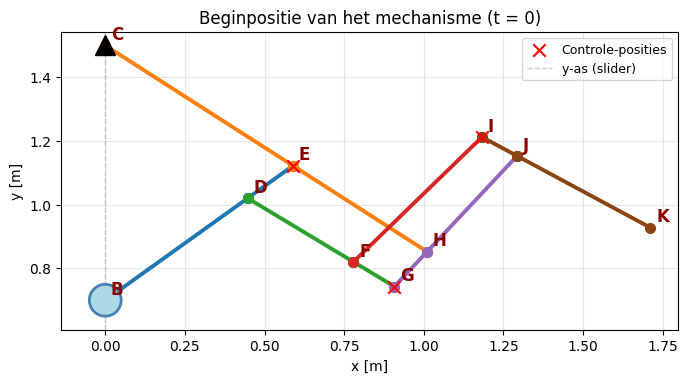

In [5]:
import matplotlib.pyplot as plt

# Los de hoeken op en bereken de posities op t=0
angles0 = get_angles(B_y[0], *geometry_parameters,
                     theta_3_init, theta_4_init, theta_5_init, theta_6_init, theta_7_init, theta_8_init)
positions0, positions0_control = get_positions(B_y[0], *angles0, *geometry_parameters)

joint_names = "BCDEFGHIJK"
joints = dict(zip(joint_names, positions0))

# Kleur per stang (oorspronkelijk schema)
colors_link = {
    ('B','D'):'tab:blue',    ('D','E'):'tab:blue',          # stang 3
    ('C','E'):'tab:orange',  ('E','H'):'tab:orange',        # stang 4
    ('D','F'):'tab:green',   ('F','G'):'tab:green',         # stang 5
    ('F','I'):'tab:red',                                    # stang 6
    ('G','H'):'tab:purple',  ('H','J'):'tab:purple',        # stang 7
    ('I','J'):'saddlebrown', ('J','K'):'saddlebrown',       # stang 8
}
connections = list(colors_link.keys())

plt.close('all')
fig, ax = plt.subplots(figsize=(7, 8))

# Teken de stangen in hun kleur
for (start, end) in connections:
    p1, p2 = joints[start], joints[end]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'o-',
            color=colors_link[(start, end)], lw=2.8, ms=7, zorder=3)

# Schuifgewricht B (lichtblauw met steelblue rand)
B0 = joints['B']
ax.add_patch(plt.Circle((B0[0], B0[1]), 0.025*L1,
             lw=2, edgecolor='steelblue', facecolor='lightblue', zorder=6))

# Vast gewricht C (zwart driehoekje)
C_pos = joints['C']
ax.plot(C_pos[0], C_pos[1], 'k^', ms=14, zorder=8)

# Controle-posities (rode kruisjes)
for nm in ['E', 'G', 'I']:
    idx = joint_names.index(nm)
    ax.scatter(positions0_control[idx, 0], positions0_control[idx, 1],
               c='red', marker='x', s=80, zorder=7,
               label='Controle-posities' if nm == 'E' else None)

# Labels in donkerrood
for key in joint_names:
    p = joints[key]
    ax.text(p[0] + 0.018, p[1] + 0.018, key,
            fontsize=12, fontweight='bold', color='darkred', zorder=9)

# Slider-as
ax.axvline(0, color='gray', lw=1, ls='--', alpha=0.4, label='y-as (slider)')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Beginpositie van het mechanisme (t = 0)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Snelheidsanalyse

In [6]:
# Solve the angular velocity of links 3..8 from the time-derivative of the loop closure system
# All 3 loops are expanded so every θ that appears in the closure (directly or through joint positions)
# contributes a column.  RHS holds the contribution of the slider speed dB_y.
def get_angular_velocity(theta_3, theta_4, theta_5, theta_6, theta_7, theta_8,
                         dB_y_k,
                         L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b):
    # Loop 1 expanded:  x_B + L3 cos θ3 − x_C − L4a cos θ4 = 0
    # Loop 2 expanded:  x_B + L3a cos θ3 + L5 cos θ5 + L7a cos θ7 − x_C − L4 cos θ4 = 0
    # Loop 3 expanded:  x_B + L3a cos θ3 + L5a cos θ5 + L6 cos θ6 + L8a cos θ8
    #                    − x_C − L4 cos θ4 − L7b cos θ7 = 0
    A = np.array([
        [-L3 *np.sin(theta_3),  L4a*np.sin(theta_4),  0,                    0,                    0,                     0                    ],
        [ L3 *np.cos(theta_3), -L4a*np.cos(theta_4),  0,                    0,                    0,                     0                    ],
        [-L3a*np.sin(theta_3),  L4 *np.sin(theta_4), -L5 *np.sin(theta_5),  0,                   -L7a*np.sin(theta_7),    0                    ],
        [ L3a*np.cos(theta_3), -L4 *np.cos(theta_4),  L5 *np.cos(theta_5),  0,                    L7a*np.cos(theta_7),    0                    ],
        [-L3a*np.sin(theta_3),  L4 *np.sin(theta_4), -L5a*np.sin(theta_5), -L6 *np.sin(theta_6),  L7b*np.sin(theta_7),   -L8a*np.sin(theta_8)  ],
        [ L3a*np.cos(theta_3), -L4 *np.cos(theta_4),  L5a*np.cos(theta_5),  L6 *np.cos(theta_6), -L7b*np.cos(theta_7),    L8a*np.cos(theta_8)  ],
    ])
    # RHS: only the y-rows carry the slider speed (x_B is fixed at 0)
    B = np.array([
         0.0,
        -dB_y_k,
         0.0,
        -dB_y_k,
         0.0,
        -dB_y_k,
    ])
    x = np.linalg.solve(A, B)
    return x  # Returns dθ3..dθ8

# Compute the linear velocity of every joint using two vector chains
def get_linear_velocity(theta_3, theta_4, theta_5, theta_6, theta_7, theta_8,
                        dtheta_3, dtheta_4, dtheta_5, dtheta_6, dtheta_7, dtheta_8,
                        dB_y_k,
                        L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b):
    # Primary chain — from slider B and fixed C
    v_B = np.array([0.0, dB_y_k, 0.0])
    v_C = np.array([0.0, 0.0,    0.0])
    v_D = v_B + np.cross([0, 0, dtheta_3], [*rotate_vector([L3a, 0], theta_3), 0])
    v_E = v_B + np.cross([0, 0, dtheta_3], [*rotate_vector([L3,  0], theta_3), 0])
    v_F = v_D + np.cross([0, 0, dtheta_5], [*rotate_vector([L5a, 0], theta_5), 0])
    v_G = v_D + np.cross([0, 0, dtheta_5], [*rotate_vector([L5,  0], theta_5), 0])
    v_H = v_C + np.cross([0, 0, dtheta_4], [*rotate_vector([L4,  0], theta_4), 0])
    v_I = v_F + np.cross([0, 0, dtheta_6], [*rotate_vector([L6,  0], theta_6), 0])
    v_J = v_H + np.cross([0, 0, dtheta_7], [*rotate_vector([L7b, 0], theta_7), 0])
    v_K = v_J + np.cross([0, 0, dtheta_8], [*rotate_vector([L8b, 0], theta_8), 0])

    # Control chain — alternative paths for E, G, I
    v_E_control = v_C + np.cross([0, 0, dtheta_4], [*rotate_vector([L4a,  0], theta_4), 0])
    v_G_control = v_H + np.cross([0, 0, dtheta_7], [*rotate_vector([-L7a, 0], theta_7), 0])
    v_I_control = v_J + np.cross([0, 0, dtheta_8], [*rotate_vector([-L8a, 0], theta_8), 0])

    primary = np.array([v_B[:2], v_C[:2], v_D[:2], v_E[:2], v_F[:2], v_G[:2], v_H[:2], v_I[:2], v_J[:2], v_K[:2]])
    control = np.array([v_B[:2], v_C[:2], v_D[:2], v_E_control[:2], v_F[:2], v_G_control[:2], v_H[:2], v_I_control[:2], v_J[:2], v_K[:2]])
    return primary, control


### Versnellingsanalyse

In [7]:
# Solve angular accelerations: same matrix A as for velocities, RHS with ω² (centripetal) terms.
# After differentiating the velocity equations once more, every cos→-sin·θ̇ term yields a
# centripetal contribution +Lk · cos·θ̇²  (sign depending on the row).
def get_angular_acceleration(theta_3, theta_4, theta_5, theta_6, theta_7, theta_8,
                             dtheta_3, dtheta_4, dtheta_5, dtheta_6, dtheta_7, dtheta_8,
                             ddB_y_k,
                             L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b):
    A = np.array([
        [-L3 *np.sin(theta_3),  L4a*np.sin(theta_4),  0,                    0,                    0,                     0                    ],
        [ L3 *np.cos(theta_3), -L4a*np.cos(theta_4),  0,                    0,                    0,                     0                    ],
        [-L3a*np.sin(theta_3),  L4 *np.sin(theta_4), -L5 *np.sin(theta_5),  0,                   -L7a*np.sin(theta_7),    0                    ],
        [ L3a*np.cos(theta_3), -L4 *np.cos(theta_4),  L5 *np.cos(theta_5),  0,                    L7a*np.cos(theta_7),    0                    ],
        [-L3a*np.sin(theta_3),  L4 *np.sin(theta_4), -L5a*np.sin(theta_5), -L6 *np.sin(theta_6),  L7b*np.sin(theta_7),   -L8a*np.sin(theta_8)  ],
        [ L3a*np.cos(theta_3), -L4 *np.cos(theta_4),  L5a*np.cos(theta_5),  L6 *np.cos(theta_6), -L7b*np.cos(theta_7),    L8a*np.cos(theta_8)  ],
    ])
    # RHS: bring every ω² term to the right-hand side.
    # For a column with +Lk sin θk in A (row x), the centripetal term on the RHS is +Lk cos θk · θ̇²;
    # for −Lk sin θk in A, the RHS gets −Lk cos θk · θ̇² ; similarly for y-rows (swap cos/sin).
    B = np.array([
        # Loop 1 — x:   d²/dt² of  L3 cos θ3 − L4a cos θ4  = 0
                                     L3 *np.cos(theta_3)*dtheta_3**2  - L4a*np.cos(theta_4)*dtheta_4**2,
        # Loop 1 — y
       -ddB_y_k                    + L3 *np.sin(theta_3)*dtheta_3**2  - L4a*np.sin(theta_4)*dtheta_4**2,
        # Loop 2 — x
                                     L3a*np.cos(theta_3)*dtheta_3**2  - L4 *np.cos(theta_4)*dtheta_4**2
                                  +  L5 *np.cos(theta_5)*dtheta_5**2  + L7a*np.cos(theta_7)*dtheta_7**2,
        # Loop 2 — y
       -ddB_y_k                    + L3a*np.sin(theta_3)*dtheta_3**2  - L4 *np.sin(theta_4)*dtheta_4**2
                                  +  L5 *np.sin(theta_5)*dtheta_5**2  + L7a*np.sin(theta_7)*dtheta_7**2,
        # Loop 3 — x
                                     L3a*np.cos(theta_3)*dtheta_3**2  - L4 *np.cos(theta_4)*dtheta_4**2
                                  +  L5a*np.cos(theta_5)*dtheta_5**2  + L6 *np.cos(theta_6)*dtheta_6**2
                                  -  L7b*np.cos(theta_7)*dtheta_7**2  + L8a*np.cos(theta_8)*dtheta_8**2,
        # Loop 3 — y
       -ddB_y_k                    + L3a*np.sin(theta_3)*dtheta_3**2  - L4 *np.sin(theta_4)*dtheta_4**2
                                  +  L5a*np.sin(theta_5)*dtheta_5**2  + L6 *np.sin(theta_6)*dtheta_6**2
                                  -  L7b*np.sin(theta_7)*dtheta_7**2  + L8a*np.sin(theta_8)*dtheta_8**2,
    ])
    x = np.linalg.solve(A, B)
    return x  # Returns ddθ3..ddθ8

# Compute the linear acceleration of every joint (primary + control)
def get_linear_acceleration(theta_3, theta_4, theta_5, theta_6, theta_7, theta_8,
                            dtheta_3, dtheta_4, dtheta_5, dtheta_6, dtheta_7, dtheta_8,
                            ddtheta_3, ddtheta_4, ddtheta_5, ddtheta_6, ddtheta_7, ddtheta_8,
                            ddB_y_k,
                            L3, L3a, L3b, L4, L4a, L4b, L5, L5a, L5b, L6, L7, L7a, L7b, L8, L8a, L8b):
    # a_Y = a_X + α × r_XY − ω² r_XY   for each rigid link XY
    def rel_acc(L_, theta_k, dtheta_k, ddtheta_k):
        r_xy = np.array(rotate_vector([L_, 0], theta_k))
        tangential = np.cross([0, 0, ddtheta_k], [r_xy[0], r_xy[1], 0])[:2]
        centripetal = -dtheta_k**2 * r_xy
        out3 = np.zeros(3); out3[0] = tangential[0] + centripetal[0]; out3[1] = tangential[1] + centripetal[1]
        return out3

    a_B = np.array([0.0, ddB_y_k, 0.0])
    a_C = np.array([0.0, 0.0,     0.0])
    a_D = a_B + rel_acc(L3a, theta_3, dtheta_3, ddtheta_3)
    a_E = a_B + rel_acc(L3,  theta_3, dtheta_3, ddtheta_3)
    a_F = a_D + rel_acc(L5a, theta_5, dtheta_5, ddtheta_5)
    a_G = a_D + rel_acc(L5,  theta_5, dtheta_5, ddtheta_5)
    a_H = a_C + rel_acc(L4,  theta_4, dtheta_4, ddtheta_4)
    a_I = a_F + rel_acc(L6,  theta_6, dtheta_6, ddtheta_6)
    a_J = a_H + rel_acc(L7b, theta_7, dtheta_7, ddtheta_7)
    a_K = a_J + rel_acc(L8b, theta_8, dtheta_8, ddtheta_8)

    a_E_control = a_C + rel_acc(L4a,  theta_4, dtheta_4, ddtheta_4)
    a_G_control = a_H + rel_acc(-L7a, theta_7, dtheta_7, ddtheta_7)
    a_I_control = a_J + rel_acc(-L8a, theta_8, dtheta_8, ddtheta_8)

    primary = np.array([a_B[:2], a_C[:2], a_D[:2], a_E[:2], a_F[:2], a_G[:2], a_H[:2], a_I[:2], a_J[:2], a_K[:2]])
    control = np.array([a_B[:2], a_C[:2], a_D[:2], a_E_control[:2], a_F[:2], a_G_control[:2], a_H[:2], a_I_control[:2], a_J[:2], a_K[:2]])
    return primary, control


Nu kunnen we voor elk tijdstip van de hele beweging het volgende berekenen:
- de hoek van elke stang,
- de positie van elk gewricht,
- de hoeksnelheid van elke stang,
- de lineaire snelheid van elk gewricht,
- de hoekversnelling van elke stang,
- de lineaire versnelling van elk gewricht,
- controle-berekeningen voor de positie, snelheid en versnelling van elk gewricht.

In [8]:
# Calculates angles, velocities and accelerations for later use
N_joints = 10  # B,C,D,E,F,G,H,I,J,K
angles                       = np.zeros((len(t), 6))                  # θ3..θ8
positions                    = np.zeros((len(t), N_joints, 2))
positions_control            = np.zeros((len(t), N_joints, 2))
joints = dict(((joint_names[i], positions[:, i, :]) for i in range(N_joints)))

angular_velocities           = np.zeros((len(t), 6))                  # dθ3..dθ8
linear_velocities            = np.zeros((len(t), N_joints, 2))
linear_velocities_control    = np.zeros((len(t), N_joints, 2))

angular_accelerations        = np.zeros((len(t), 6))                  # ddθ3..ddθ8
linear_accelerations         = np.zeros((len(t), N_joints, 2))
linear_accelerations_control = np.zeros((len(t), N_joints, 2))

# Warm-started initial guesses
guess = [theta_3_init, theta_4_init, theta_5_init, theta_6_init, theta_7_init, theta_8_init]

for i in range(len(t)):
    angles[i] = get_angles(B_y[i], *geometry_parameters, *guess)
    guess = list(angles[i])  # warm start for next step
    positions[i], positions_control[i] = get_positions(B_y[i], *angles[i], *geometry_parameters)

    angular_velocities[i] = get_angular_velocity(*angles[i], dB_y[i], *link_parameters)
    linear_velocities[i], linear_velocities_control[i] = get_linear_velocity(
        *angles[i], *angular_velocities[i], dB_y[i], *link_parameters)

    angular_accelerations[i] = get_angular_acceleration(*angles[i], *angular_velocities[i], ddB_y[i], *link_parameters)
    linear_accelerations[i], linear_accelerations_control[i] = get_linear_acceleration(
        *angles[i], *angular_velocities[i], *angular_accelerations[i], ddB_y[i], *link_parameters)

theta_3, dtheta_3, ddtheta_3 = angles[:, 0], angular_velocities[:, 0], angular_accelerations[:, 0]
theta_4, dtheta_4, ddtheta_4 = angles[:, 1], angular_velocities[:, 1], angular_accelerations[:, 1]
theta_5, dtheta_5, ddtheta_5 = angles[:, 2], angular_velocities[:, 2], angular_accelerations[:, 2]
theta_6, dtheta_6, ddtheta_6 = angles[:, 3], angular_velocities[:, 3], angular_accelerations[:, 3]
theta_7, dtheta_7, ddtheta_7 = angles[:, 4], angular_velocities[:, 4], angular_accelerations[:, 4]
theta_8, dtheta_8, ddtheta_8 = angles[:, 5], angular_velocities[:, 5], angular_accelerations[:, 5]

print(f'Kinematics computed for {len(t)} time steps')
print(f'θ3 range: [{np.degrees(theta_3.min()):+.1f}°, {np.degrees(theta_3.max()):+.1f}°]')


Kinematics computed for 253 time steps
θ3 range: [+23.2°, +51.3°]


### Plots
We tonen eerst een animatie van het mechanisme.
- De slider B beweegt langs de y-as (de verticale lijn) — wanneer B hoog staat is de paraplu **dicht**, wanneer B laag staat is hij **open**.

In [9]:
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150
plt.ioff()
fig, ax = plt.subplots()

# Frame-budget (ongeveer 50 frames per cyclus, zoals in de referentie)
n_frames = 50
frame_step = max(1, len(t) // n_frames)

# Plot-grenzen
all_x = np.concatenate([positions[:, :, 0].flatten(), [x_C]])
all_y = np.concatenate([positions[:, :, 1].flatten(), [y_C]])
m = 0.08 * L1
xl, xr = all_x.min() - m, all_x.max() + m
yb, yt = all_y.min() - m, all_y.max() + m

# Kleur per stang
colors_link = {
    ('B','D'):'tab:blue',    ('D','E'):'tab:blue',
    ('C','E'):'tab:orange',  ('E','H'):'tab:orange',
    ('D','F'):'tab:green',   ('F','G'):'tab:green',
    ('F','I'):'tab:red',
    ('G','H'):'tab:purple',  ('H','J'):'tab:purple',
    ('I','J'):'saddlebrown', ('J','K'):'saddlebrown',
}
connections_anim = list(colors_link.keys())

def animate(i):
    i *= frame_step
    if i >= len(t):
        i = len(t) - 1
    plt.cla()
    assembly = positions[i]

    # Teken de stangen in hun kleur
    for (start, end) in connections_anim:
        i1 = joint_names.index(start)
        i2 = joint_names.index(end)
        p1, p2 = assembly[i1], assembly[i2]
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'o-',
                 color=colors_link[(start, end)], lw=2.5, ms=6, zorder=3)

    # Slider B (lichtblauw met steelblue rand)
    B_k = assembly[0]
    plt.gca().add_patch(plt.Circle((B_k[0], B_k[1]), 0.02*L1,
                        lw=2, edgecolor='steelblue', facecolor='lightblue', zorder=6))

    # Vast gewricht C (zwart driehoekje)
    plt.plot(x_C, y_C, 'k^', ms=12, zorder=8)

    # Labels in donkerrood
    for key in joint_names:
        idx = joint_names.index(key)
        p = assembly[idx]
        plt.text(p[0] + 0.018, p[1] + 0.018, key,
                 fontsize=10, fontweight='bold', color='darkred', zorder=9)

    # Verticale slider-as
    plt.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)

    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.title(r'$B_y$ = {:.3f} m;  $t$ = {:.2f} s'.format(B_y[i], t[i]))
    plt.grid(True, alpha=0.3)
    plt.xlim(xl, xr)
    plt.ylim(yb, yt)

# Zelfde afspeelsnelheid als de referentie: interval = Ts * 2000 ms per frame
matplotlib.animation.FuncAnimation(fig, animate, frames=range(n_frames), interval=Ts * 2000)


#### Positie-plots

##### Fouten op de positieberekeningen

- De geldigheid van de positieberekening is geverifieerd door de positie van een gewricht op twee verschillende manieren te berekenen.
- Dit gebeurt door een andere 'keten' van relatieve posities te kiezen: vertrek vanuit een vast gewricht (bv. C) en werk je weg naar de andere gewrichten via $p_\text{Y} = p_{\text{abs},X} + p_{\text{rel},XY}$.

**Nauwkeurigheid van de fouten**
- De positiecontroles gebruiken twee verschillende vectorketens om dezelfde gewrichtspositie te berekenen, beide gebaseerd op hoeken gevonden door SciPy's `fsolve`.
- `fsolve` lost een niet-lineair stelsel op, wat inherent minder precies is dan directe (lineaire) oplossers door iteratieve benadering en convergentie-toleranties.
- De hoeken uit `fsolve` zijn slechts nauwkeurig tot op een zekere tolerantie (standaard rond $10^{-8}$), waardoor kleine afwijkingen doorwerken in de berekende posities.
- Relatieve fouten zijn iets groter dan absolute fouten (rond $10^{-9}$) omdat ze gedeeld worden door (kleine) positiewaarden, wat de verhouding versterkt.
- Deze foutenniveaus zijn normaal voor niet-lineaire numerieke oplossers en bevestigen dat de oplossing nauwkeurig is binnen de verwachte limiet van drijvende-komma- en oplosser-tolerantie.

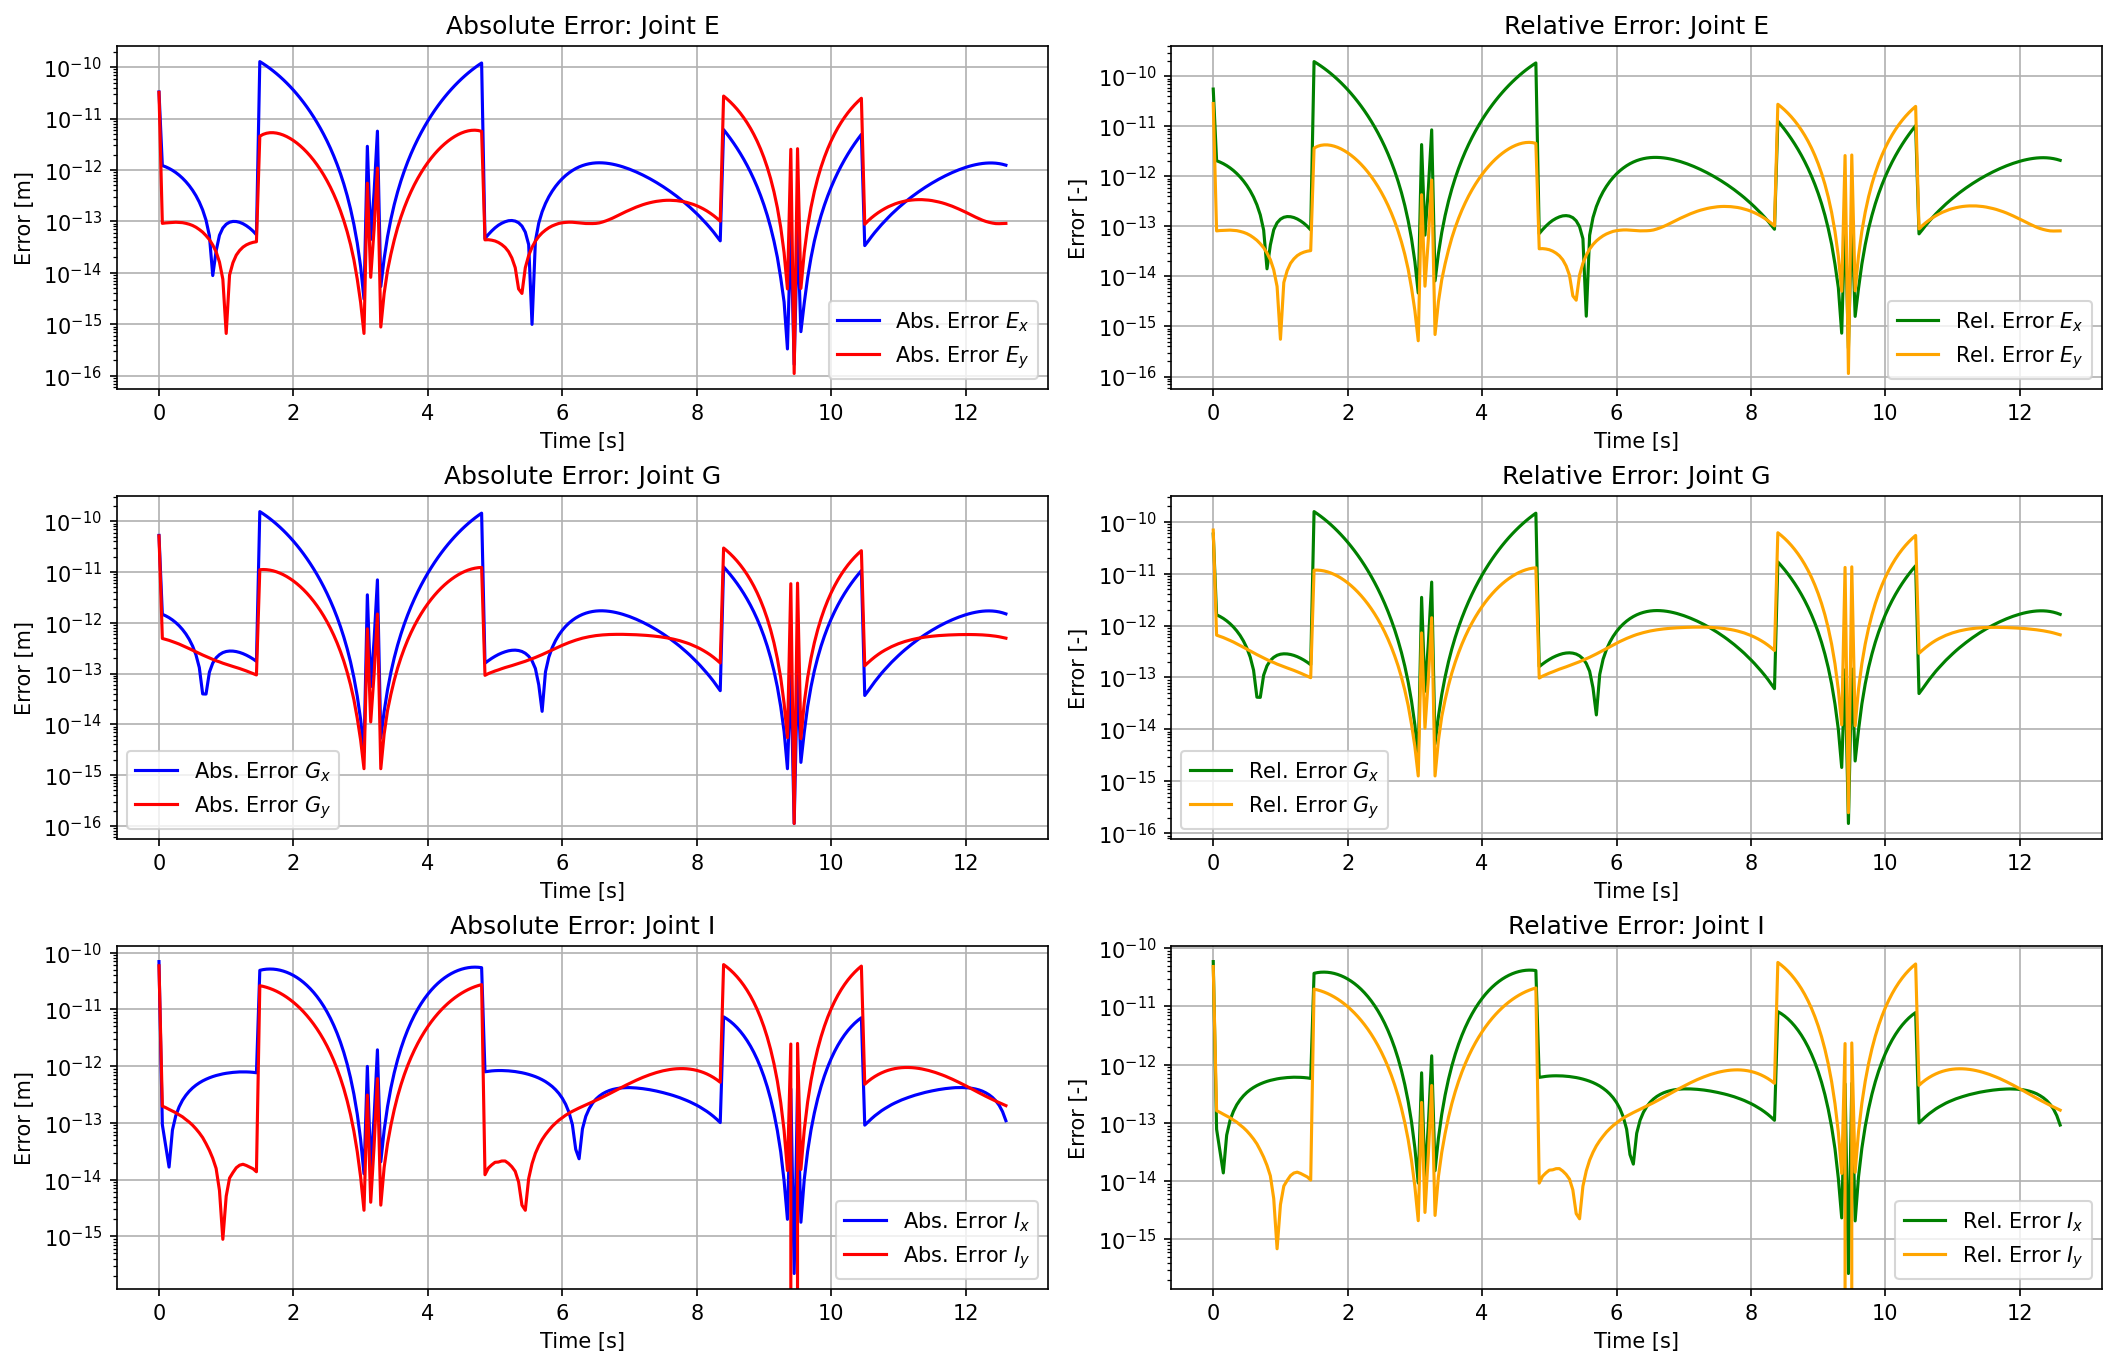

In [10]:
# Create subplots for absolute and relative errors of the cross-checked joints (E, G, I)
plt.close('all')
checked_joints = ['E', 'G', 'I']
fig, axes = plt.subplots(len(checked_joints), 2, figsize=(14, 3*len(checked_joints)), constrained_layout=True)

for i, joint in enumerate(checked_joints):
    index = joint_names.index(joint)
    absolute_errors = np.abs(positions[:, index, :] - positions_control[:, index, :])
    relative_errors = np.abs(absolute_errors / np.where(np.abs(positions[:, index, :]) > 1e-12, positions[:, index, :], 1e-12))

    # Absolute error plots
    axes[i, 0].plot(t, absolute_errors[:, 0], label=f'Abs. Error ${joint}_x$', color='blue')
    axes[i, 0].plot(t, absolute_errors[:, 1], label=f'Abs. Error ${joint}_y$', color='red')
    axes[i, 0].set_title(f'Absolute Error: Joint {joint}')
    axes[i, 0].set_xlabel('Time [s]')
    axes[i, 0].set_ylabel('Error [m]')
    axes[i, 0].set_yscale('log')
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # Relative error plots
    axes[i, 1].plot(t, relative_errors[:, 0], label=f'Rel. Error ${joint}_x$', color='green')
    axes[i, 1].plot(t, relative_errors[:, 1], label=f'Rel. Error ${joint}_y$', color='orange')
    axes[i, 1].set_title(f'Relative Error: Joint {joint}')
    axes[i, 1].set_xlabel('Time [s]')
    axes[i, 1].set_ylabel('Error [-]')
    axes[i, 1].set_yscale('log')
    axes[i, 1].grid(True)
    axes[i, 1].legend()

plt.show()


#### Hoeksnelheid-plots

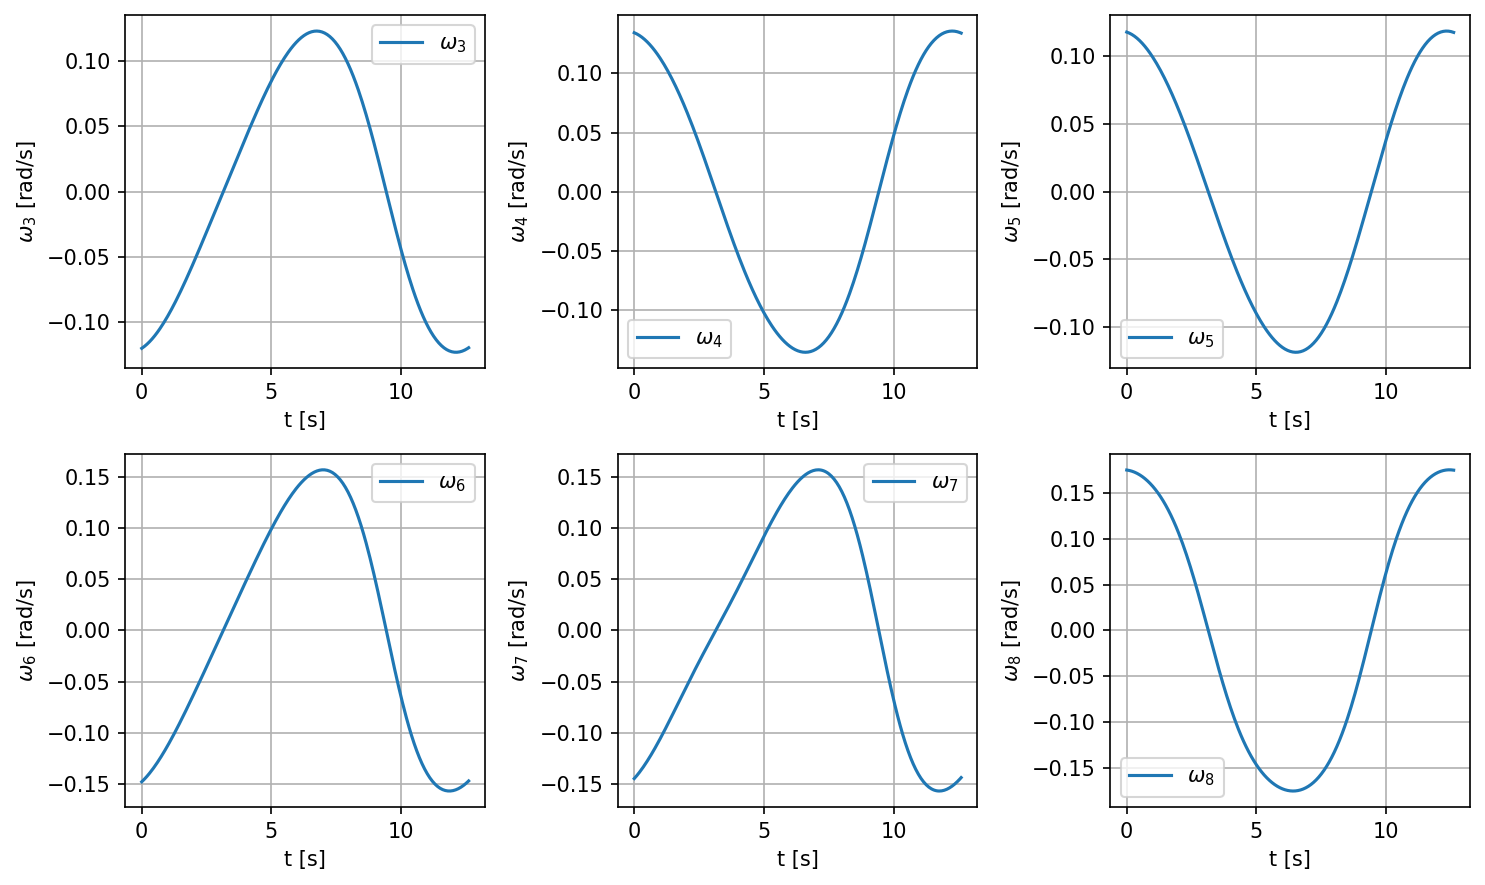

In [11]:
# Plot angular velocities with respect to time in subplots
plt.close('all')
plt.ion()
plt.figure(figsize=(10, 6))

dtheta_packed = [dtheta_3, dtheta_4, dtheta_5, dtheta_6, dtheta_7, dtheta_8]
labels = [r'$\omega_3$', r'$\omega_4$', r'$\omega_5$', r'$\omega_6$', r'$\omega_7$', r'$\omega_8$']

for i, (dtheta, label) in enumerate(zip(dtheta_packed, labels), start=1):
    plt.subplot(2, 3, i)
    plt.plot(t, dtheta, label=label)
    plt.ylabel(f'{label} [rad/s]')
    plt.xlabel('t [s]')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


#### Lineaire-snelheid-plots

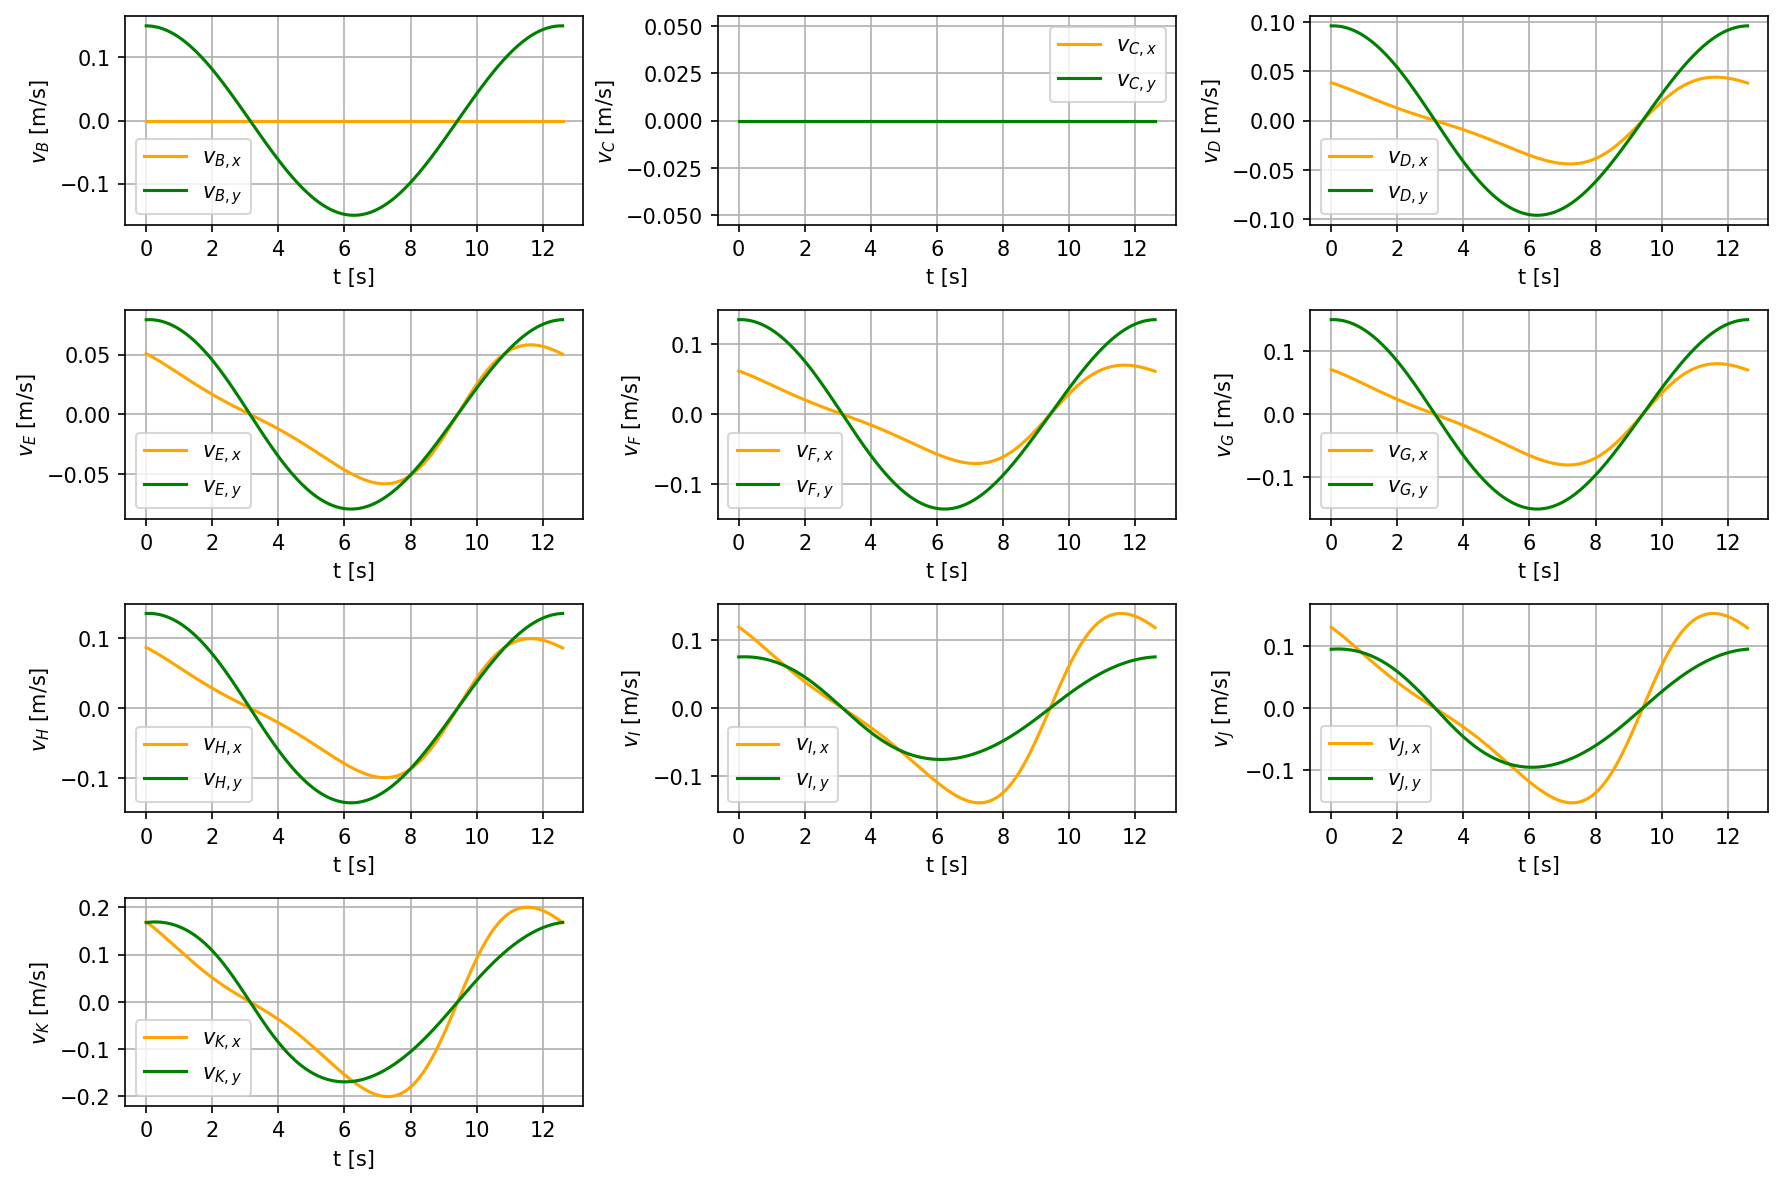

In [12]:
# Plot linear velocities with respect to time in subplots
plt.close('all')
plt.ion()
plt.figure(figsize=(12, 8))

v_packed = [(linear_velocities[:, i, :], joint) for i, joint in enumerate(joint_names)]
n = len(v_packed)
ncols = 3
nrows = (n + ncols - 1) // ncols

for i, (v, label) in enumerate(v_packed, start=1):
    plt.subplot(nrows, ncols, i)
    plt.plot(t, v[:, 0], label='$v_{' + label + ',x}$', color='orange')
    plt.plot(t, v[:, 1], label='$v_{' + label + ',y}$', color='green')
    plt.ylabel(f'$v_{label}$ [m/s]')
    plt.xlabel('t [s]')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


##### Fouten op de lineaire-snelheidsberekeningen

- De geldigheid van de lineaire-snelheidsberekening is geverifieerd door de snelheid van een gewricht op twee verschillende manieren te berekenen.
- Dit gebeurt door een andere 'keten' van relatieve snelheden te kiezen: vertrek vanuit een vast gewricht (bv. C) en werk je weg naar de andere gewrichten via $v_\text{Y} = v_{\text{abs},X} + v_{\text{rel},XY}$.

**Nauwkeurigheid van de fouten**
- De lineaire snelheden worden berekend via een vectorketen. Hierin gebruiken we hoeksnelheden die volgen uit het oplossen van een **lineair stelsel vergelijkingen**.
- Zo'n klein stelsel kan **direct** opgelost worden door een oplosalgoritme. De resultaten zijn **exact** als we drijvende-komma-afrondingen negeren.
- Absolute fouten in de snelheidsvalidatie zijn vaak exact nul, omdat beide vectorketens hetzelfde rekentraject volgen.
- Kleine niet-nul fouten (typisch $10^{-18}$ tot $10^{-16}$) komen door drijvende-komma-afronding en de volgorde van rekenkundige bewerkingen.
- Deze fouten zijn verwacht en bevestigen dat beide berekeningsmethoden wiskundig equivalent en numeriek stabiel zijn.
- De gemeten foutenniveaus bevestigen de correctheid en hoge numerieke nauwkeurigheid van de kinematische implementatie.

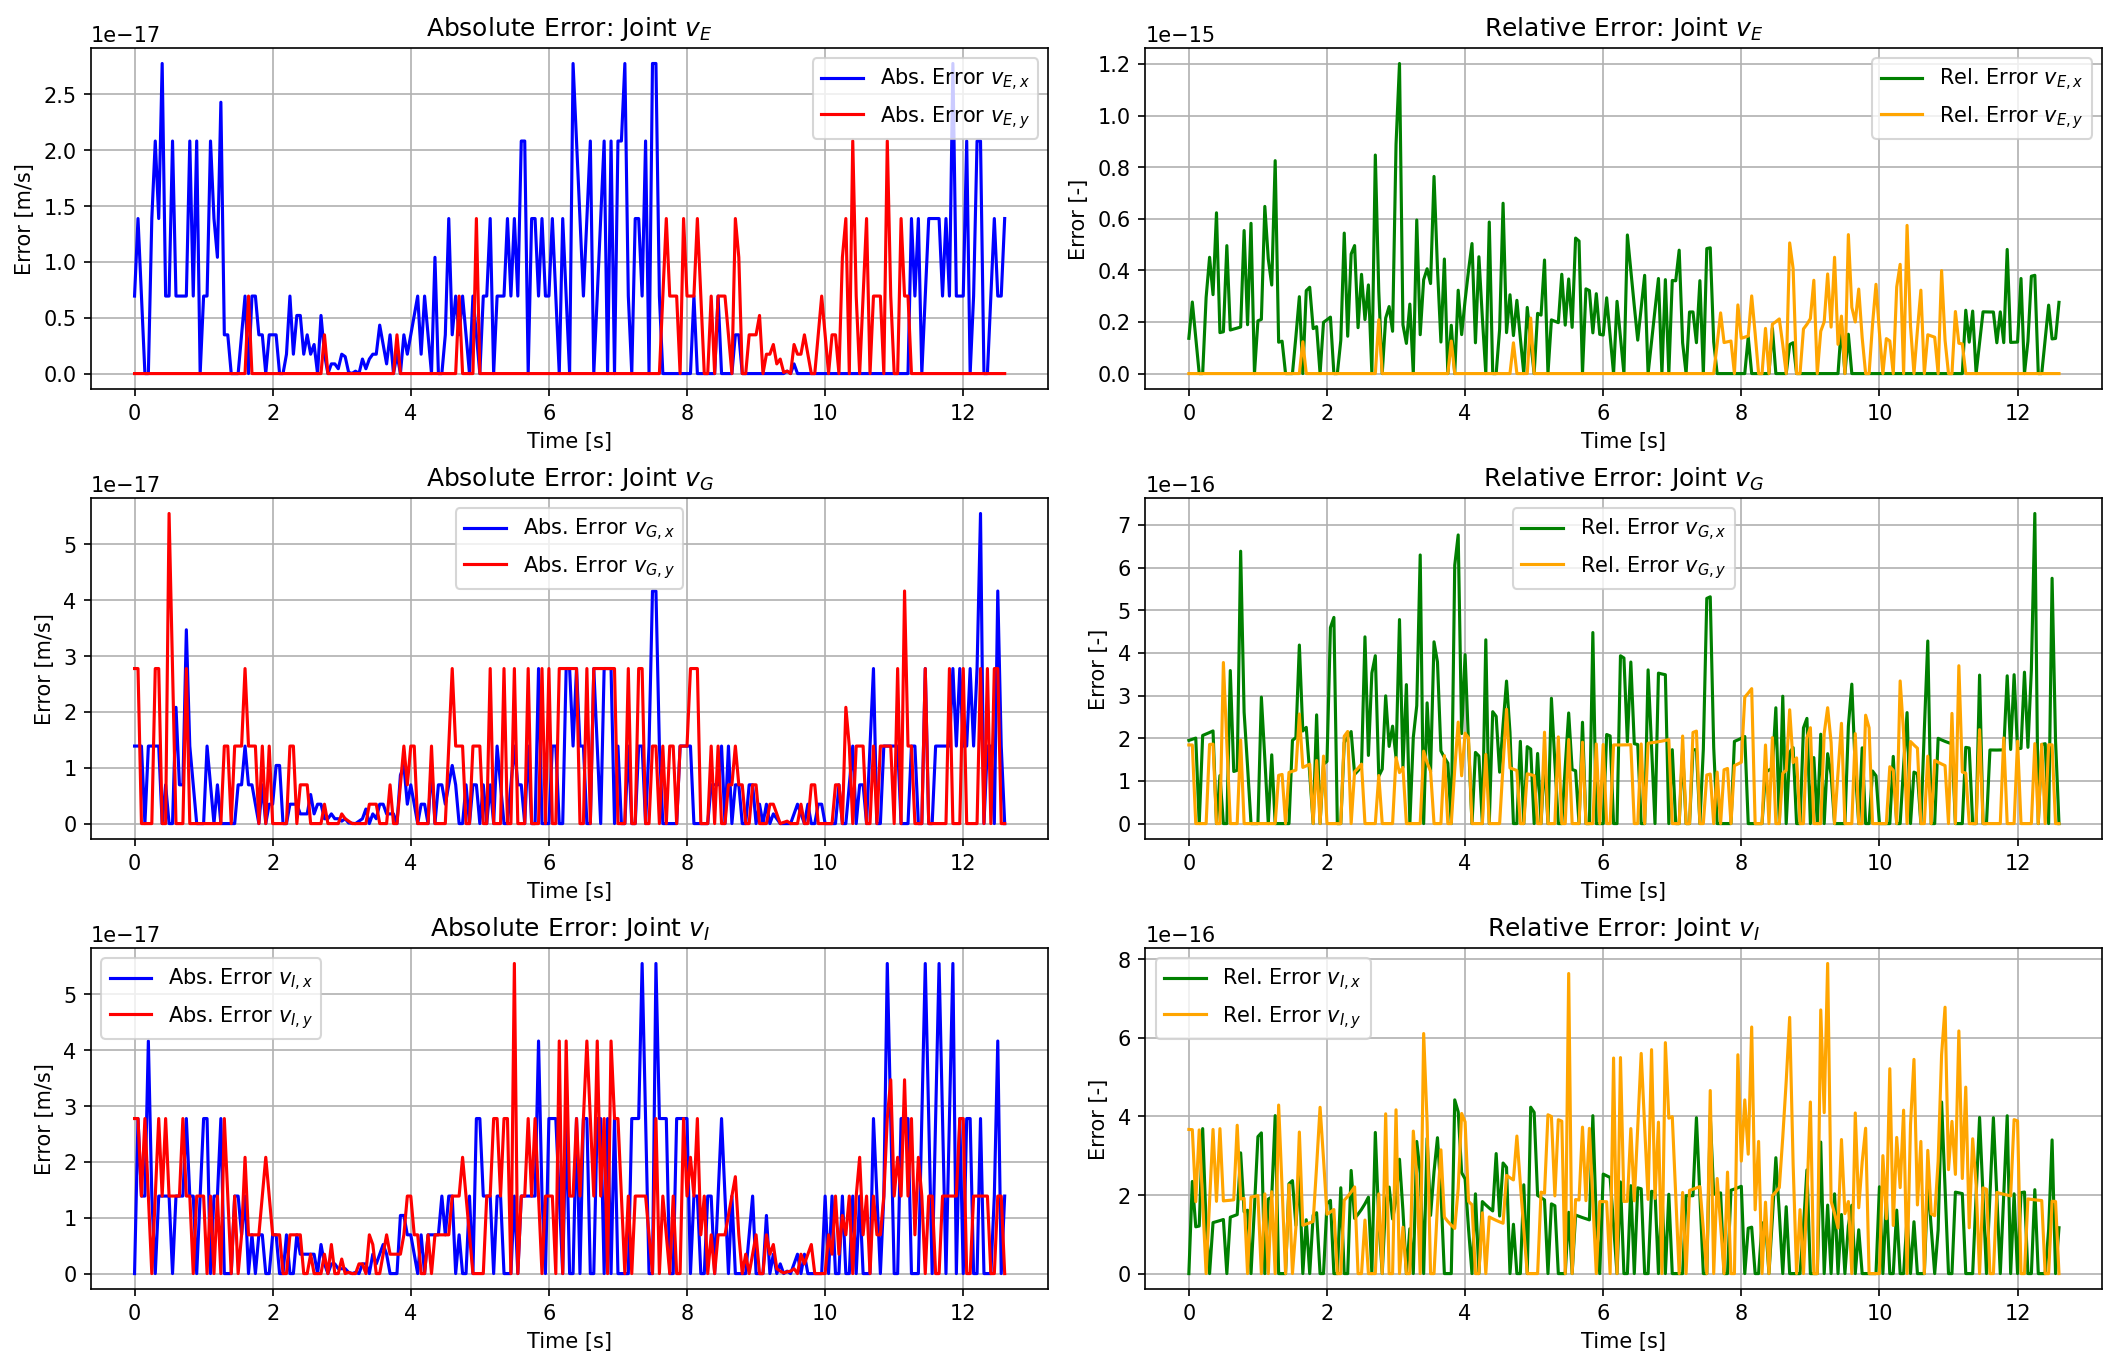

In [13]:
# Create subplots for absolute and relative errors
plt.close('all')
checked_joints = ['E', 'G', 'I']
fig, axes = plt.subplots(len(checked_joints), 2, figsize=(14, 3*len(checked_joints)), constrained_layout=True)

for i, joint in enumerate(checked_joints):
    index = joint_names.index(joint)
    absolute_errors = np.abs(linear_velocities[:, index, :] - linear_velocities_control[:, index, :])
    denom = np.where(np.abs(linear_velocities[:, index, :]) > 1e-12, linear_velocities[:, index, :], 1e-12)
    relative_errors = np.abs(absolute_errors / denom)

    axes[i, 0].plot(t, absolute_errors[:, 0], label='Abs. Error $v_{' + joint + ',x}$', color='blue')
    axes[i, 0].plot(t, absolute_errors[:, 1], label='Abs. Error $v_{' + joint + ',y}$', color='red')
    axes[i, 0].set_title('Absolute Error: Joint $v_{' + joint + '}$')
    axes[i, 0].set_xlabel('Time [s]')
    axes[i, 0].set_ylabel('Error [m/s]')
    axes[i, 0].grid(True); axes[i, 0].legend()

    axes[i, 1].plot(t, relative_errors[:, 0], label='Rel. Error $v_{' + joint + ',x}$', color='green')
    axes[i, 1].plot(t, relative_errors[:, 1], label='Rel. Error $v_{' + joint + ',y}$', color='orange')
    axes[i, 1].set_title('Relative Error: Joint $v_{' + joint + '}$')
    axes[i, 1].set_xlabel('Time [s]')
    axes[i, 1].set_ylabel('Error [-]')
    axes[i, 1].grid(True); axes[i, 1].legend()

plt.show()


#### Hoekversnelling-plots

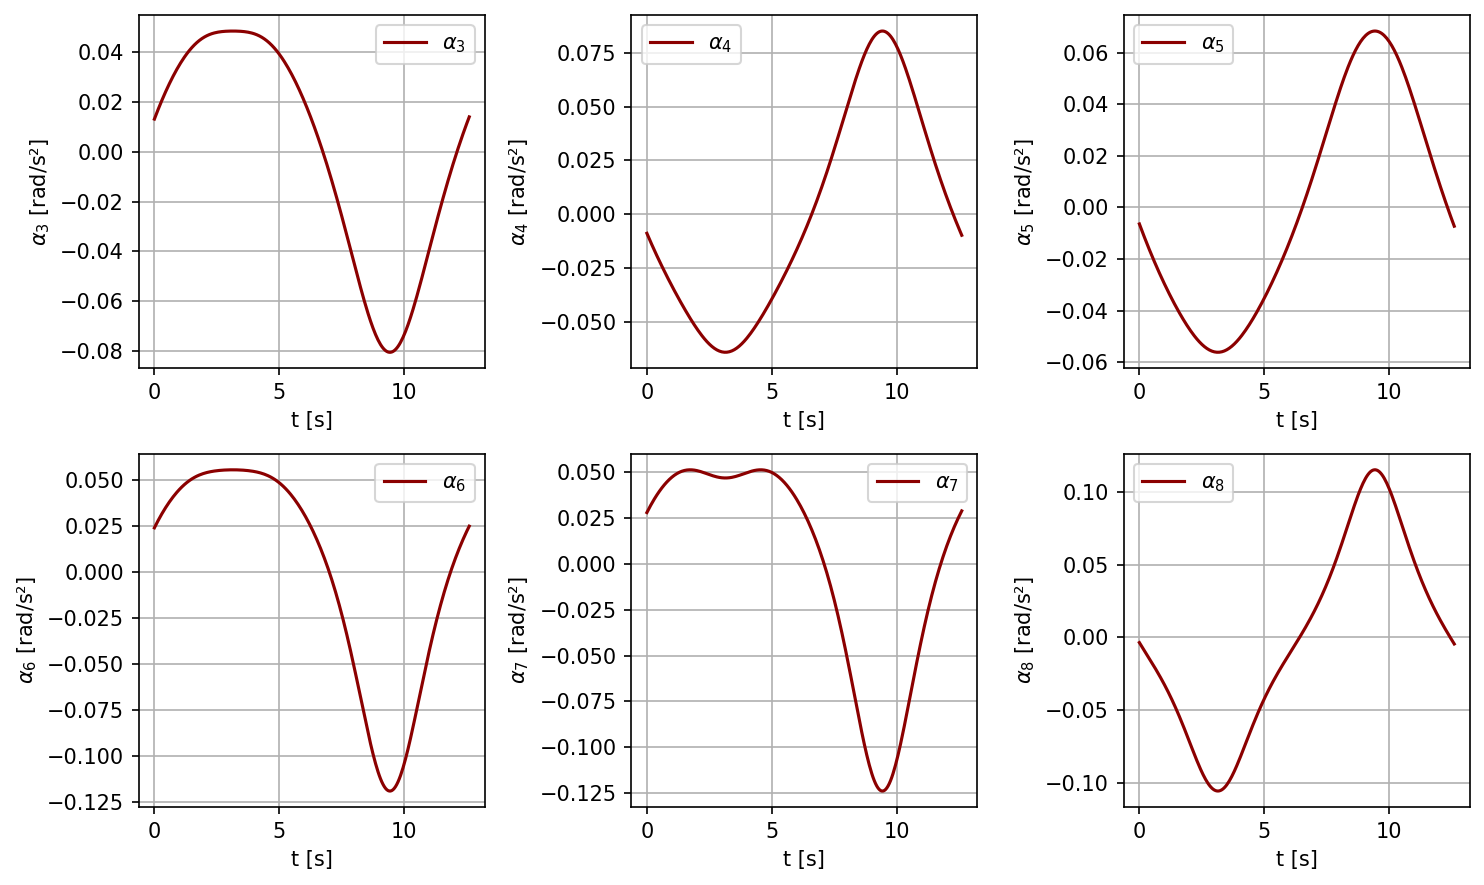

In [14]:
# Plot angular accelerations with respect to time in subplots
plt.close('all')
plt.ion()
plt.figure(figsize=(10, 6))

ddtheta_packed = [ddtheta_3, ddtheta_4, ddtheta_5, ddtheta_6, ddtheta_7, ddtheta_8]
labels = [r'$\alpha_3$', r'$\alpha_4$', r'$\alpha_5$', r'$\alpha_6$', r'$\alpha_7$', r'$\alpha_8$']

for i, (ddtheta, label) in enumerate(zip(ddtheta_packed, labels), start=1):
    plt.subplot(2, 3, i)
    plt.plot(t, ddtheta, label=label, color='darkred')
    plt.ylabel(f'{label} [rad/s²]')
    plt.xlabel('t [s]')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


#### Lineaire-versnelling-plots

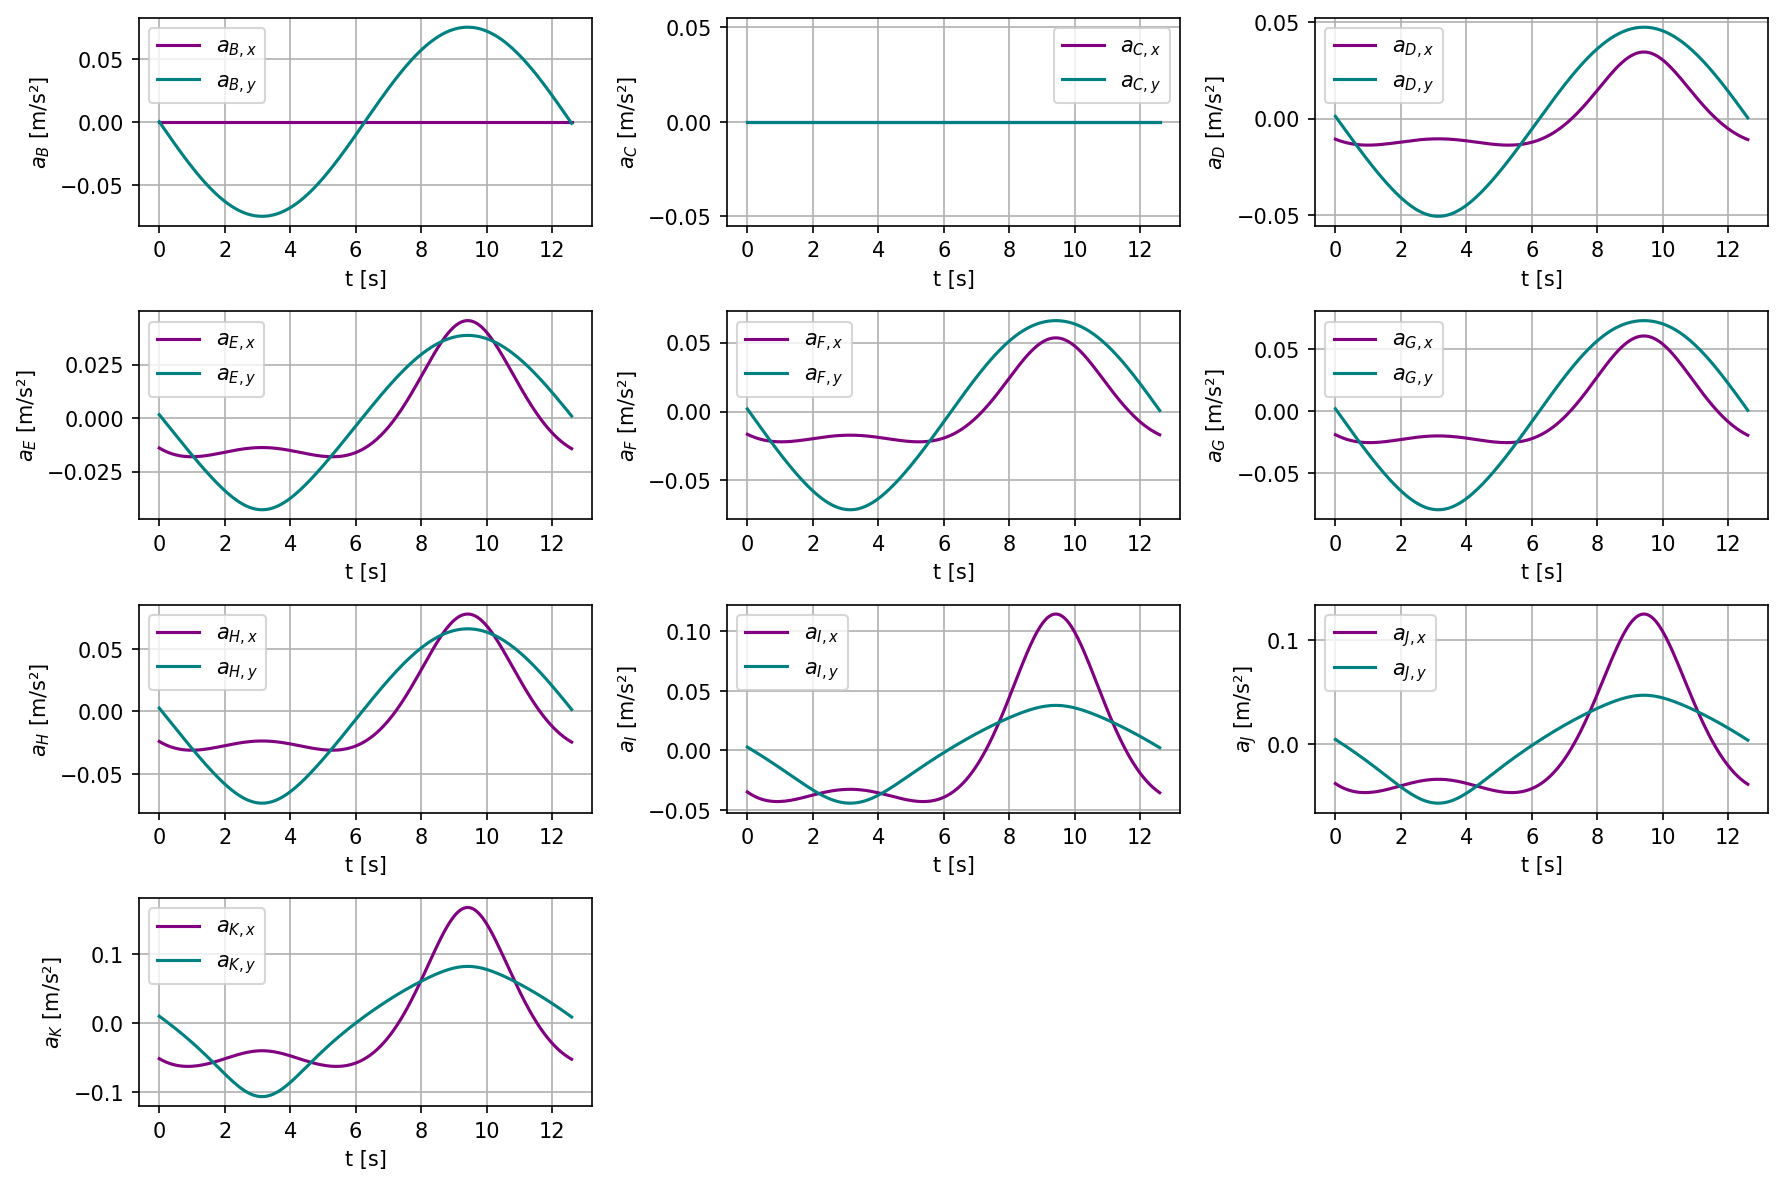

In [15]:
# Plot linear accelerations with respect to time in subplots
plt.close('all')
plt.ion()
plt.figure(figsize=(12, 8))

a_packed = [(linear_accelerations[:, i, :], joint) for i, joint in enumerate(joint_names)]
n = len(a_packed)
ncols = 3
nrows = (n + ncols - 1) // ncols

for i, (a, label) in enumerate(a_packed, start=1):
    plt.subplot(nrows, ncols, i)
    plt.plot(t, a[:, 0], label='$a_{' + label + ',x}$', color='purple')
    plt.plot(t, a[:, 1], label='$a_{' + label + ',y}$', color='teal')
    plt.ylabel(f'$a_{label}$ [m/s²]')
    plt.xlabel('t [s]')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


##### Fouten op de lineaire-versnellingsberekeningen

- De geldigheid van de lineaire-versnellingsberekening is geverifieerd door de versnelling van een gewricht op twee verschillende manieren te berekenen.
- Dit gebeurt door een andere 'keten' van relatieve versnellingen te kiezen: vertrek vanuit een vast gewricht (bv. C) en werk je weg via relatieve versnellingen.

**Nauwkeurigheid van de fouten**
- De lineaire versnellingen worden berekend via een vectorketen. Hierin gebruiken we hoeksnelheden en hoekversnellingen die volgen uit het oplossen van **lineaire stelsels vergelijkingen**.
- Zo'n klein stelsel kan **direct** opgelost worden. De resultaten zijn **exact** als we drijvende-komma-afrondingen negeren.
- Absolute fouten in de versnellingsvalidatie zijn vaak exact nul, omdat beide vectorketens hetzelfde rekentraject volgen.
- Kleine niet-nul fouten (typisch $10^{-18}$ tot $10^{-16}$) komen door drijvende-komma-afronding en de volgorde van rekenkundige bewerkingen.
- De gemeten foutenniveaus bevestigen de correctheid en hoge numerieke nauwkeurigheid van de kinematische implementatie.

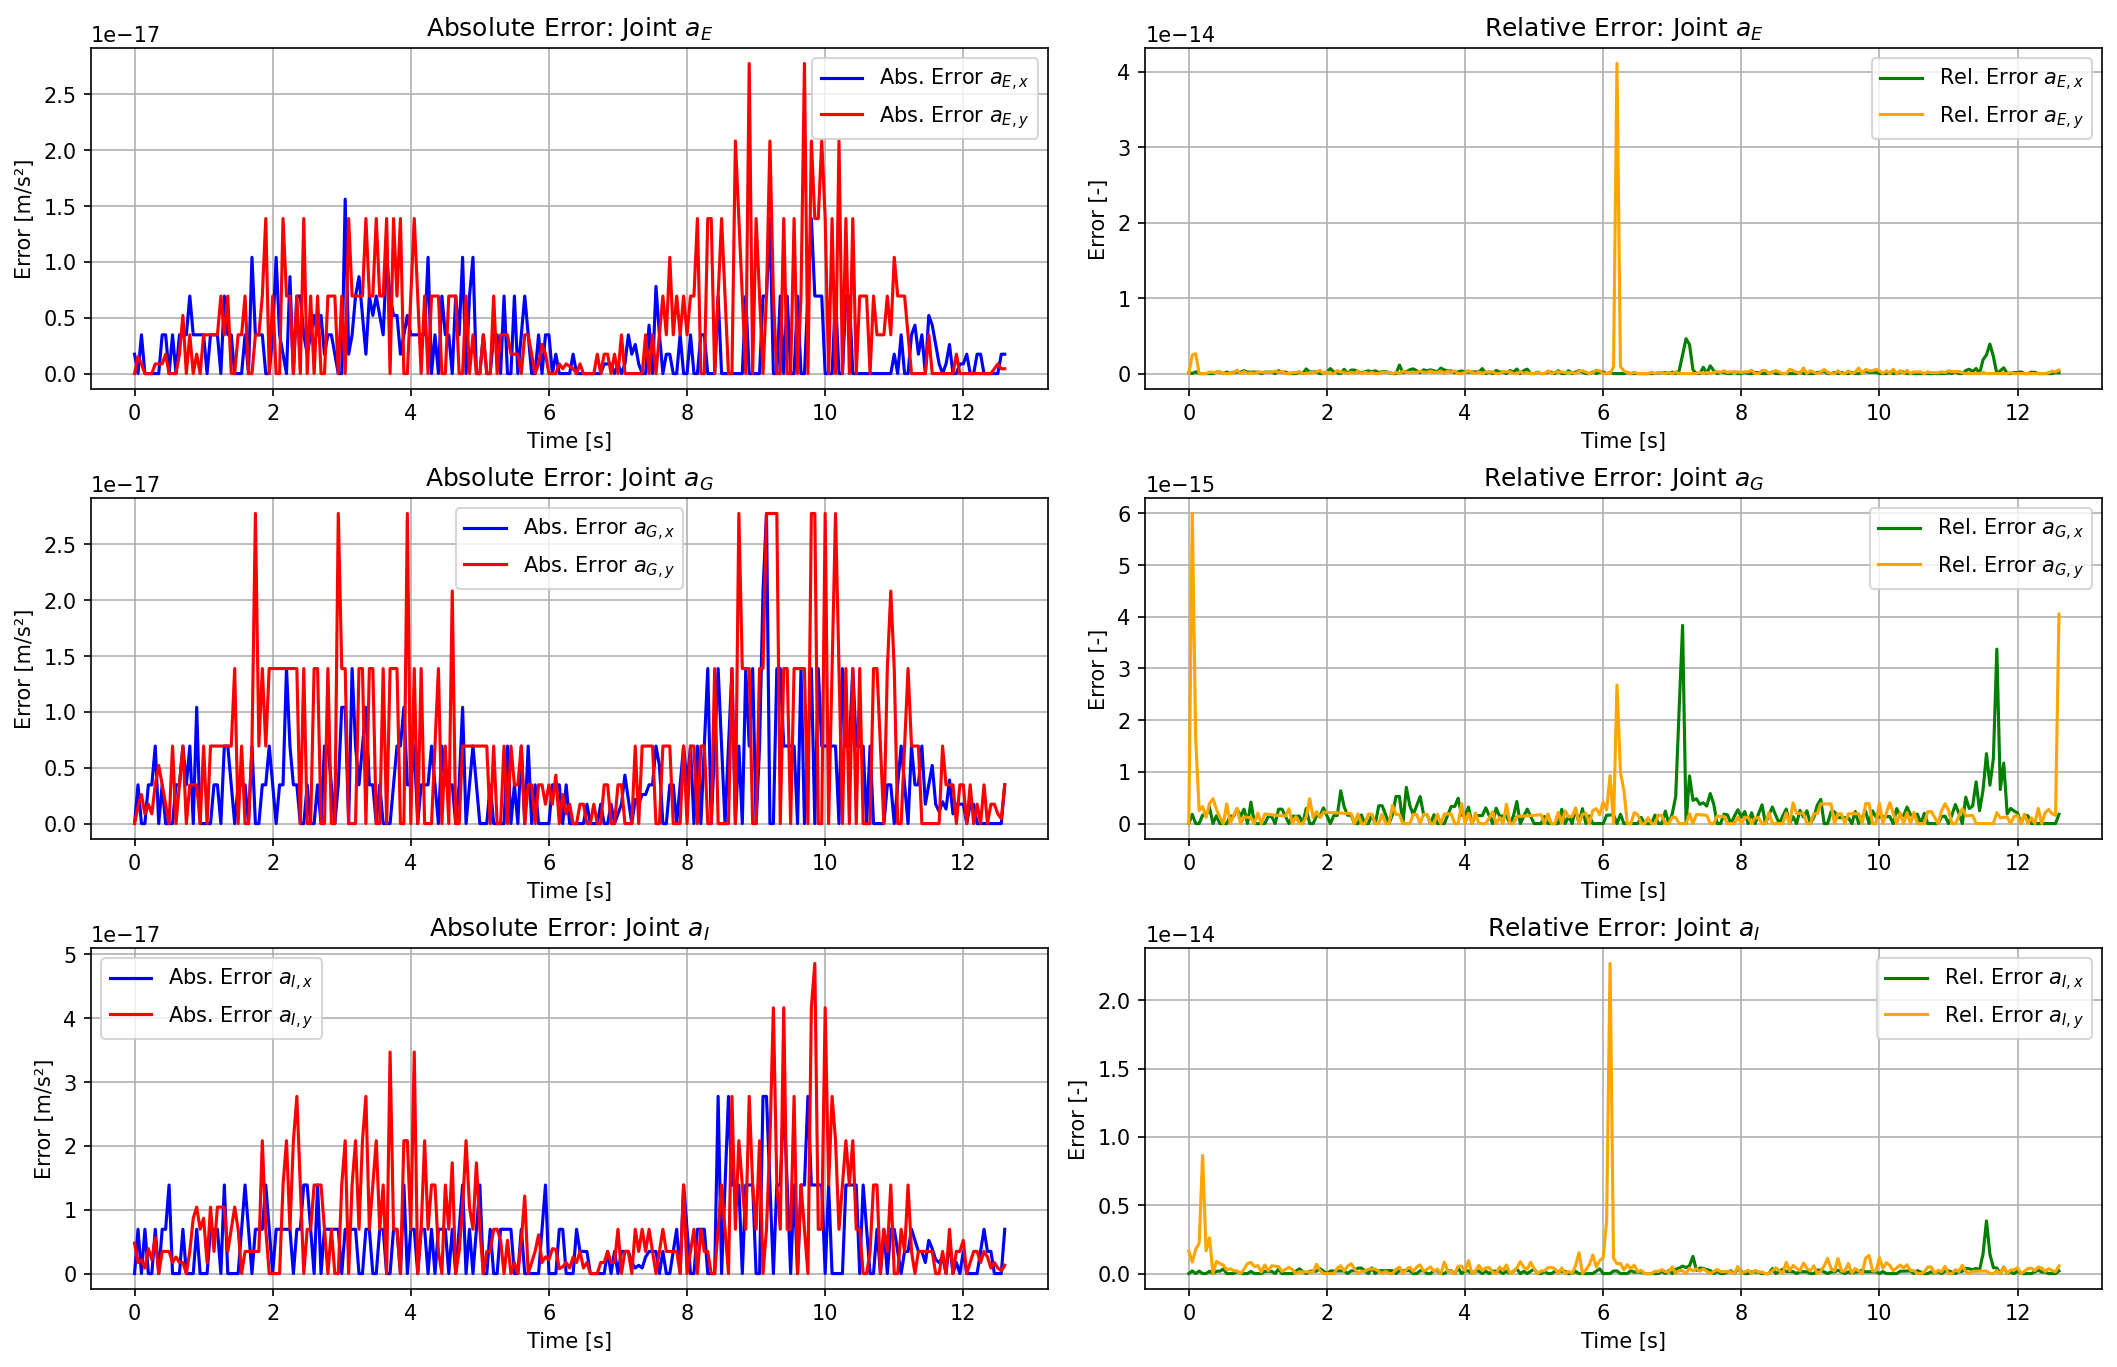

In [16]:
# Create subplots for absolute and relative errors
plt.close('all')
checked_joints = ['E', 'G', 'I']
fig, axes = plt.subplots(len(checked_joints), 2, figsize=(14, 3*len(checked_joints)), constrained_layout=True)

for i, joint in enumerate(checked_joints):
    index = joint_names.index(joint)
    absolute_errors = np.abs(linear_accelerations[:, index, :] - linear_accelerations_control[:, index, :])
    denom = np.where(np.abs(linear_accelerations[:, index, :]) > 1e-12, linear_accelerations[:, index, :], 1e-12)
    relative_errors = np.abs(absolute_errors / denom)

    axes[i, 0].plot(t, absolute_errors[:, 0], label='Abs. Error $a_{' + joint + ',x}$', color='blue')
    axes[i, 0].plot(t, absolute_errors[:, 1], label='Abs. Error $a_{' + joint + ',y}$', color='red')
    axes[i, 0].set_title('Absolute Error: Joint $a_{' + joint + '}$')
    axes[i, 0].set_xlabel('Time [s]')
    axes[i, 0].set_ylabel('Error [m/s²]')
    axes[i, 0].grid(True); axes[i, 0].legend()

    axes[i, 1].plot(t, relative_errors[:, 0], label='Rel. Error $a_{' + joint + ',x}$', color='green')
    axes[i, 1].plot(t, relative_errors[:, 1], label='Rel. Error $a_{' + joint + ',y}$', color='orange')
    axes[i, 1].set_title('Relative Error: Joint $a_{' + joint + '}$')
    axes[i, 1].set_xlabel('Time [s]')
    axes[i, 1].set_ylabel('Error [-]')
    axes[i, 1].grid(True); axes[i, 1].legend()

plt.show()


## Dynamische analyse

De onbekenden zijn:
- twee componenten van de reactiekracht in elk scharnier (X en Y),
- behalve in scharnieren waar 3 stangen samenkomen — daar is er een extra paar (de kracht op de derde stang),
- de vereiste aandrijfkracht aan de slider B (langs y; de x-reactie van de prismatische geleiding is ook onbekend).

Voor elk van de 6 bewegende stangen hebben we de kracht- en moment-evenwichten:

$\sum F_x = m a_x$,

$\sum F_y = m a_y$,

$\sum M_z + \sum \vec{r} \times \vec{F} = I \alpha$.

Er zijn 6 bewegende stangen (3..8). Tellen we de reactiekracht-paren in elk gewricht (B intern, D intern, E ternair 2×, F intern, G intern, H ternair 2×, I intern, J ternair 2×, K vrij) plus 2 grondreacties in C en 2 in de slider B (één langs y is de aandrijfkracht, de andere is de x-reactie van de prismatische geleiding), dan komen we uit op **20 onbekenden en 18 + 2 (sliderbeperking) = 20 vergelijkingen**, die we als één lineair stelsel oplossen per tijdstap.

Hieronder de vrij-lichaamsdiagrammen van elke stang.


In [17]:
#<!-- ![alt text](Images/FBD_Bar3.png "Free body diagram Bar 3") -->
#<img src="Images/Bar 3.png" alt="drawing" width="700"/>

In [18]:
#<!-- ![alt text](Images/FBD_Bar4.png "Free body diagram Bar 4") -->
#<img src="Images/Bar 4.png" alt="drawing" width="700"/>

In [19]:
#<!-- ![alt text](Images/FBD_Bar5.png "Free body diagram Bar 5") -->
#<img src="Images/Bar 5.png" alt="drawing" width="700"/>

In [20]:
#<!-- ![alt text](Images/FBD_Bar6.png "Free body diagram Bar 6") -->
#<img src="Images/Bar 6.png" alt="drawing" width="700"/>

In [21]:
#<!-- ![alt text](Images/FBD_Bar7.png "Free body diagram Bar 7") -->
#<img src="Images/Bar 7.png" alt="drawing" width="700"/>

In [22]:
#<!-- ![alt text](Images/FBD_Bar8.png "Free body diagram Bar 8") -->
#<img src="Images/Bar 8.png" alt="drawing" width="700"/>

We stellen eerst alle bekende variabelen voor:

In [23]:
# Dynamic parameters, defined in a local frame on each of the bars.
# Each link is modelled as a uniform slender rod ⇒ CoG halfway along the bar,
# inertia I = m L² / 12 about the CoG.
g = 9.81  # m/s²  (gravity acts along -y)

# Material / cross-section
rho = 7800           # kg/m³  (steel)
d_cross = 0.02       # m  (rod diameter)
mass_per_length = rho * np.pi / 4 * d_cross**2   # kg/m

# Masses (each link is one rigid rod of total length L_k)
m3 = L3 * mass_per_length
m4 = L4 * mass_per_length
m5 = L5 * mass_per_length
m6 = L6 * mass_per_length
m7 = L7 * mass_per_length
m8 = L8 * mass_per_length

# Inertia about CoG (slender rod)
J3 = m3 * L3**2 / 12
J4 = m4 * L4**2 / 12
J5 = m5 * L5**2 / 12
J6 = m6 * L6**2 / 12
J7 = m7 * L7**2 / 12
J8 = m8 * L8**2 / 12

# Position of CoG along each link, measured from the local origin point
# (chosen so that links are oriented along their +x local axis at angle θk)
#   link 3 origin = B,  end point = E,  CoG at midpoint of B-E segment   ⇒ x = L3/2
#   link 4 origin = C,  end point = H                                    ⇒ x = L4/2
#   link 5 origin = D,  end point = G                                    ⇒ x = L5/2
#   link 6 origin = F,  end point = I                                    ⇒ x = L6/2
#   link 7 origin = G,  end point = J                                    ⇒ x = L7/2
#   link 8 origin = I,  end point = K                                    ⇒ x = L8/2
X3, X4, X5, X6, X7, X8 = L3/2, L4/2, L5/2, L6/2, L7/2, L8/2

# Vector from CoG to each attachment point (in world frame, time-varying)
# Link 3 (origin B, attaches at B, D, E with offsets 0, L3a, L3 along link axis θ3)
cog3_B_x = (0   - X3) * np.cos(theta_3); cog3_B_y = (0   - X3) * np.sin(theta_3)
cog3_D_x = (L3a - X3) * np.cos(theta_3); cog3_D_y = (L3a - X3) * np.sin(theta_3)
cog3_E_x = (L3  - X3) * np.cos(theta_3); cog3_E_y = (L3  - X3) * np.sin(theta_3)

# Link 4 (origin C, offsets 0, L4a, L4)
cog4_C_x = (0   - X4) * np.cos(theta_4); cog4_C_y = (0   - X4) * np.sin(theta_4)
cog4_E_x = (L4a - X4) * np.cos(theta_4); cog4_E_y = (L4a - X4) * np.sin(theta_4)
cog4_H_x = (L4  - X4) * np.cos(theta_4); cog4_H_y = (L4  - X4) * np.sin(theta_4)

# Link 5 (origin D, offsets 0, L5a, L5)
cog5_D_x = (0   - X5) * np.cos(theta_5); cog5_D_y = (0   - X5) * np.sin(theta_5)
cog5_F_x = (L5a - X5) * np.cos(theta_5); cog5_F_y = (L5a - X5) * np.sin(theta_5)
cog5_G_x = (L5  - X5) * np.cos(theta_5); cog5_G_y = (L5  - X5) * np.sin(theta_5)

# Link 6 (origin F, offsets 0, L6)
cog6_F_x = (0   - X6) * np.cos(theta_6); cog6_F_y = (0   - X6) * np.sin(theta_6)
cog6_I_x = (L6  - X6) * np.cos(theta_6); cog6_I_y = (L6  - X6) * np.sin(theta_6)

# Link 7 (origin G, offsets 0, L7a, L7)  →  G — H — J
cog7_G_x = (0   - X7) * np.cos(theta_7); cog7_G_y = (0   - X7) * np.sin(theta_7)
cog7_H_x = (L7a - X7) * np.cos(theta_7); cog7_H_y = (L7a - X7) * np.sin(theta_7)
cog7_J_x = (L7  - X7) * np.cos(theta_7); cog7_J_y = (L7  - X7) * np.sin(theta_7)

# Link 8 (origin I, offsets 0, L8a, L8)  →  I — J — K
cog8_I_x = (0   - X8) * np.cos(theta_8); cog8_I_y = (0   - X8) * np.sin(theta_8)
cog8_J_x = (L8a - X8) * np.cos(theta_8); cog8_J_y = (L8a - X8) * np.sin(theta_8)
cog8_K_x = (L8  - X8) * np.cos(theta_8); cog8_K_y = (L8  - X8) * np.sin(theta_8)

print(f"Masses [kg]:  m3={m3:.4f}  m4={m4:.4f}  m5={m5:.4f}  m6={m6:.4f}  m7={m7:.4f}  m8={m8:.4f}")
print(f"Total moving mass = {m3+m4+m5+m6+m7+m8:.4f} kg")


Masses [kg]:  m3=1.7766  m4=2.9405  m5=1.3171  m6=1.3784  m7=1.3784  m8=1.4703
Total moving mass = 10.2612 kg


Aangezien de kracht- en moment-evenwichten betrokken zijn op het massacentrum, moeten we de versnelling van het massacentrum van elke stang berekenen:

In [24]:
# Position of the CoG of each link in world coordinates (time-varying)
# cog_k = origin_k + (X_k cos θk, X_k sin θk)
# where origin_k is one of the joints
pos_B = positions[:, joint_names.index("B"), :]
pos_C = np.tile([x_C, y_C], (len(t), 1))
pos_D = positions[:, joint_names.index("D"), :]
pos_F = positions[:, joint_names.index("F"), :]
pos_G = positions[:, joint_names.index("G"), :]
pos_I = positions[:, joint_names.index("I"), :]

cog3 = pos_B + np.column_stack((X3*np.cos(theta_3), X3*np.sin(theta_3)))
cog4 = pos_C + np.column_stack((X4*np.cos(theta_4), X4*np.sin(theta_4)))
cog5 = pos_D + np.column_stack((X5*np.cos(theta_5), X5*np.sin(theta_5)))
cog6 = pos_F + np.column_stack((X6*np.cos(theta_6), X6*np.sin(theta_6)))
cog7 = pos_G + np.column_stack((X7*np.cos(theta_7), X7*np.sin(theta_7)))
cog8 = pos_I + np.column_stack((X8*np.cos(theta_8), X8*np.sin(theta_8)))

# Accelerations of the CoG: a_cog = a_origin + α × r_cog/origin − ω² r_cog/origin
# We use the same vector-chain formulation as in the kinematic part.
a_B_vec = linear_accelerations[:, joint_names.index("B"), :]
a_C_vec = np.zeros((len(t), 2))
a_D_vec = linear_accelerations[:, joint_names.index("D"), :]
a_F_vec = linear_accelerations[:, joint_names.index("F"), :]
a_G_vec = linear_accelerations[:, joint_names.index("G"), :]
a_I_vec = linear_accelerations[:, joint_names.index("I"), :]

def acc_cog(a_origin, X_local, theta_k, dtheta_k, ddtheta_k):
    rx = X_local * np.cos(theta_k);  ry = X_local * np.sin(theta_k)
    # α × r  in 2D → (−ddtheta·ry, +ddtheta·rx);  −ω² r → (−dtheta²·rx, −dtheta²·ry)
    ax = a_origin[:, 0] - ddtheta_k * ry - dtheta_k**2 * rx
    ay = a_origin[:, 1] + ddtheta_k * rx - dtheta_k**2 * ry
    return np.column_stack((ax, ay))

acc_cog3 = acc_cog(a_B_vec, X3, theta_3, dtheta_3, ddtheta_3)
acc_cog4 = acc_cog(a_C_vec, X4, theta_4, dtheta_4, ddtheta_4)
acc_cog5 = acc_cog(a_D_vec, X5, theta_5, dtheta_5, ddtheta_5)
acc_cog6 = acc_cog(a_F_vec, X6, theta_6, dtheta_6, ddtheta_6)
acc_cog7 = acc_cog(a_G_vec, X7, theta_7, dtheta_7, ddtheta_7)
acc_cog8 = acc_cog(a_I_vec, X8, theta_8, dtheta_8, ddtheta_8)

# Velocities of the CoG (needed for the energy check later)
v_B_vec = linear_velocities[:, joint_names.index("B"), :]
v_D_vec = linear_velocities[:, joint_names.index("D"), :]
v_F_vec = linear_velocities[:, joint_names.index("F"), :]
v_G_vec = linear_velocities[:, joint_names.index("G"), :]
v_I_vec = linear_velocities[:, joint_names.index("I"), :]

def vel_cog(v_origin, X_local, theta_k, dtheta_k):
    rx = X_local * np.cos(theta_k);  ry = X_local * np.sin(theta_k)
    vx = v_origin[:, 0] - dtheta_k * ry
    vy = v_origin[:, 1] + dtheta_k * rx
    return np.column_stack((vx, vy))

vel_cog3 = vel_cog(v_B_vec, X3, theta_3, dtheta_3)
vel_cog4 = vel_cog(np.zeros((len(t),2)), X4, theta_4, dtheta_4)
vel_cog5 = vel_cog(v_D_vec, X5, theta_5, dtheta_5)
vel_cog6 = vel_cog(v_F_vec, X6, theta_6, dtheta_6)
vel_cog7 = vel_cog(v_G_vec, X7, theta_7, dtheta_7)
vel_cog8 = vel_cog(v_I_vec, X8, theta_8, dtheta_8)

print("CoG kinematics computed.")
print(f"  Max |a_cog_K-bearing link 8|: {np.linalg.norm(acc_cog8, axis=1).max():.3f} m/s²")


CoG kinematics computed.
  Max |a_cog_K-bearing link 8|: 0.153 m/s²


Nu kunnen we de reactiekrachten en de vereiste aandrijfkracht berekenen voor de opgelegde beweging:

In [25]:
# Unknowns (20):
#   0,1   F_B_x  on link 3, F_B_y  on link 3   (slider reaction on link 3)
#   2,3   F_D_x3, F_D_y3                       (internal at D, link3 side)
#   4,5   F_D_x5, F_D_y5                       (internal at D, link5 side)
#   6,7   F_E_x3, F_E_y3                       (internal at E, link3 side)
#   8,9   F_E_x4, F_E_y4                       (internal at E, link4 side)
#  10,11  F_C_x, F_C_y                         (ground reaction at C on link 4)
#  12,13  F_H_x4, F_H_y4                       (internal at H, link4 side)
#  14,15  F_H_x7, F_H_y7                       (internal at H, link7 side)
#  16,17  F_F_x5, F_F_y5                       (internal at F, link5 side)
#  18,19  F_F_x6, F_F_y6                       (internal at F, link6 side)
#  20,21  F_G_x5, F_G_y5                       (internal at G, link5 side)
#  22,23  F_G_x7, F_G_y7                       (internal at G, link7 side)
#  24,25  F_I_x6, F_I_y6                       (internal at I, link6 side)
#  26,27  F_I_x8, F_I_y8                       (internal at I, link8 side)
#  28,29  F_J_x7, F_J_y7                       (internal at J, link7 side)
#  30,31  F_J_x8, F_J_y8                       (internal at J, link8 side)
#  32     F_drive  =  driving force at slider (along +y), applied on link 3 at B
# Note: F_B_x already encodes the prismatic-guide reaction at the slider.
#   At a hinge, Newton's 3rd law: F_on_link_X + F_on_link_Y = 0 → 2 equations per hinge.
N_unk = 33

F_B_x  = np.zeros_like(t); F_B_y  = np.zeros_like(t)
F_D_x  = np.zeros_like(t); F_D_y  = np.zeros_like(t)
F_E_x  = np.zeros_like(t); F_E_y  = np.zeros_like(t)
F_C_x  = np.zeros_like(t); F_C_y  = np.zeros_like(t)
F_H_x  = np.zeros_like(t); F_H_y  = np.zeros_like(t)
F_F_x  = np.zeros_like(t); F_F_y  = np.zeros_like(t)
F_G_x  = np.zeros_like(t); F_G_y  = np.zeros_like(t)
F_I_x  = np.zeros_like(t); F_I_y  = np.zeros_like(t)
F_J_x  = np.zeros_like(t); F_J_y  = np.zeros_like(t)
F_drive = np.zeros_like(t)

for i in range(len(t)):
    A = np.zeros((N_unk, N_unk))
    b = np.zeros(N_unk)

    # ── Link 3 (rod B-D-E, mass m3) ────────────────────────────────
    # Forces acting on link 3: F_B (slider reaction + drive), F_D3, F_E3, gravity, inertia
    # ΣFx: F_B_x + F_D_x3 + F_E_x3 = m3 acc_cog3_x
    A[0,0]=1; A[0,2]=1; A[0,6]=1
    b[0] = m3 * acc_cog3[i,0]
    # ΣFy: F_B_y + F_D_y3 + F_E_y3 + F_drive − m3 g = m3 acc_cog3_y
    A[1,1]=1; A[1,3]=1; A[1,7]=1; A[1,32]=1
    b[1] = m3 * acc_cog3[i,1] + m3*g
    # Moments about CoG: r_B×F_B + r_D×F_D3 + r_E×F_E3 + r_B×(0, F_drive) = J3 α3
    # r × F (z-comp) = rx*Fy − ry*Fx
    A[2,0] = -cog3_B_y[i]; A[2,1] =  cog3_B_x[i]      # F_B contribution
    A[2,2] = -cog3_D_y[i]; A[2,3] =  cog3_D_x[i]      # F_D3
    A[2,6] = -cog3_E_y[i]; A[2,7] =  cog3_E_x[i]      # F_E3
    A[2,32] =  cog3_B_x[i]                            # F_drive (along y) at B
    b[2] = J3 * ddtheta_3[i]

    # ── Link 4 (rod C-E-H, mass m4) ────────────────────────────────
    # Forces: F_C, F_E4, F_H4, gravity, inertia
    # Newton 3rd at E: F_E4 = -F_E3  → F_E_x4 = -F_E_x3, F_E_y4 = -F_E_y3
    A[3,10]=1; A[3,8]=1; A[3,12]=1
    b[3] = m4*acc_cog4[i,0]
    A[4,11]=1; A[4,9]=1; A[4,13]=1
    b[4] = m4*acc_cog4[i,1] + m4*g
    # Moments about CoG of link 4
    A[5,10] = -cog4_C_y[i]; A[5,11] =  cog4_C_x[i]
    A[5,8 ] = -cog4_E_y[i]; A[5,9 ] =  cog4_E_x[i]
    A[5,12] = -cog4_H_y[i]; A[5,13] =  cog4_H_x[i]
    b[5] = J4 * ddtheta_4[i]
    # Newton 3rd law at E (2 eqs):  F_E_x3 + F_E_x4 = 0,  F_E_y3 + F_E_y4 = 0
    A[6,6]=1;  A[6,8]=1
    A[7,7]=1;  A[7,9]=1

    # ── Link 5 (rod D-F-G, mass m5) ────────────────────────────────
    A[8,4]=1;  A[8,16]=1; A[8,20]=1
    b[8] = m5*acc_cog5[i,0]
    A[9,5]=1;  A[9,17]=1; A[9,21]=1
    b[9] = m5*acc_cog5[i,1] + m5*g
    A[10,4 ] = -cog5_D_y[i]; A[10,5 ] =  cog5_D_x[i]
    A[10,16] = -cog5_F_y[i]; A[10,17] =  cog5_F_x[i]
    A[10,20] = -cog5_G_y[i]; A[10,21] =  cog5_G_x[i]
    b[10] = J5 * ddtheta_5[i]
    # Newton 3rd at D: F_D3 + F_D5 = 0
    A[11,2]=1; A[11,4]=1
    A[12,3]=1; A[12,5]=1

    # ── Link 6 (rod F-I, mass m6) ──────────────────────────────────
    A[13,18]=1; A[13,24]=1
    b[13] = m6*acc_cog6[i,0]
    A[14,19]=1; A[14,25]=1
    b[14] = m6*acc_cog6[i,1] + m6*g
    A[15,18] = -cog6_F_y[i]; A[15,19] =  cog6_F_x[i]
    A[15,24] = -cog6_I_y[i]; A[15,25] =  cog6_I_x[i]
    b[15] = J6 * ddtheta_6[i]
    # Newton 3rd at F: F_F5 + F_F6 = 0
    A[16,16]=1; A[16,18]=1
    A[17,17]=1; A[17,19]=1

    # ── Link 7 (rod G-H-J, mass m7) ────────────────────────────────
    A[18,22]=1; A[18,14]=1; A[18,28]=1
    b[18] = m7*acc_cog7[i,0]
    A[19,23]=1; A[19,15]=1; A[19,29]=1
    b[19] = m7*acc_cog7[i,1] + m7*g
    A[20,22] = -cog7_G_y[i]; A[20,23] =  cog7_G_x[i]
    A[20,14] = -cog7_H_y[i]; A[20,15] =  cog7_H_x[i]
    A[20,28] = -cog7_J_y[i]; A[20,29] =  cog7_J_x[i]
    b[20] = J7 * ddtheta_7[i]
    # Newton 3rd at G: F_G5 + F_G7 = 0
    A[21,20]=1; A[21,22]=1
    A[22,21]=1; A[22,23]=1
    # Newton 3rd at H: F_H4 + F_H7 = 0
    A[23,12]=1; A[23,14]=1
    A[24,13]=1; A[24,15]=1

    # ── Link 8 (rod I-J-K, mass m8) ────────────────────────────────
    # K is free (tip), no force there
    A[25,26]=1; A[25,30]=1
    b[25] = m8*acc_cog8[i,0]
    A[26,27]=1; A[26,31]=1
    b[26] = m8*acc_cog8[i,1] + m8*g
    A[27,26] = -cog8_I_y[i]; A[27,27] =  cog8_I_x[i]
    A[27,30] = -cog8_J_y[i]; A[27,31] =  cog8_J_x[i]
    b[27] = J8 * ddtheta_8[i]
    # Newton 3rd at I: F_I6 + F_I8 = 0
    A[28,24]=1; A[28,26]=1
    A[29,25]=1; A[29,27]=1
    # Newton 3rd at J: F_J7 + F_J8 = 0
    A[30,28]=1; A[30,30]=1
    A[31,29]=1; A[31,31]=1

    # ── Driving / constraint at the slider B ───────────────────────
    # Prismatic slider along y ⇒ no friction along y ⇒ F_B_y on link 3 from the guide is 0,
    # the only y-force is the drive itself, already encoded as F_drive.
    A[32,1] = 1   # F_B_y (guide reaction) = 0

    sol = np.linalg.solve(A, b)
    F_B_x[i]=sol[0];  F_B_y[i]=sol[1]
    F_D_x[i]=sol[2];  F_D_y[i]=sol[3]    # on link 3 side (= -F_D on link 5 side)
    F_E_x[i]=sol[6];  F_E_y[i]=sol[7]
    F_C_x[i]=sol[10]; F_C_y[i]=sol[11]
    F_H_x[i]=sol[12]; F_H_y[i]=sol[13]
    F_F_x[i]=sol[16]; F_F_y[i]=sol[17]
    F_G_x[i]=sol[20]; F_G_y[i]=sol[21]
    F_I_x[i]=sol[24]; F_I_y[i]=sol[25]
    F_J_x[i]=sol[28]; F_J_y[i]=sol[29]
    F_drive[i] = sol[32]

print(f'F_drive ∈ [{F_drive.min():.3f}, {F_drive.max():.3f}] N')
print(f'|F_C|_max = {np.hypot(F_C_x, F_C_y).max():.3f} N')


F_drive ∈ [68.370, 75.713] N
|F_C|_max = 176.922 N


### Plots (dynamische analyse)
Reactiekrachten in de gewrichten van het mechanisme.

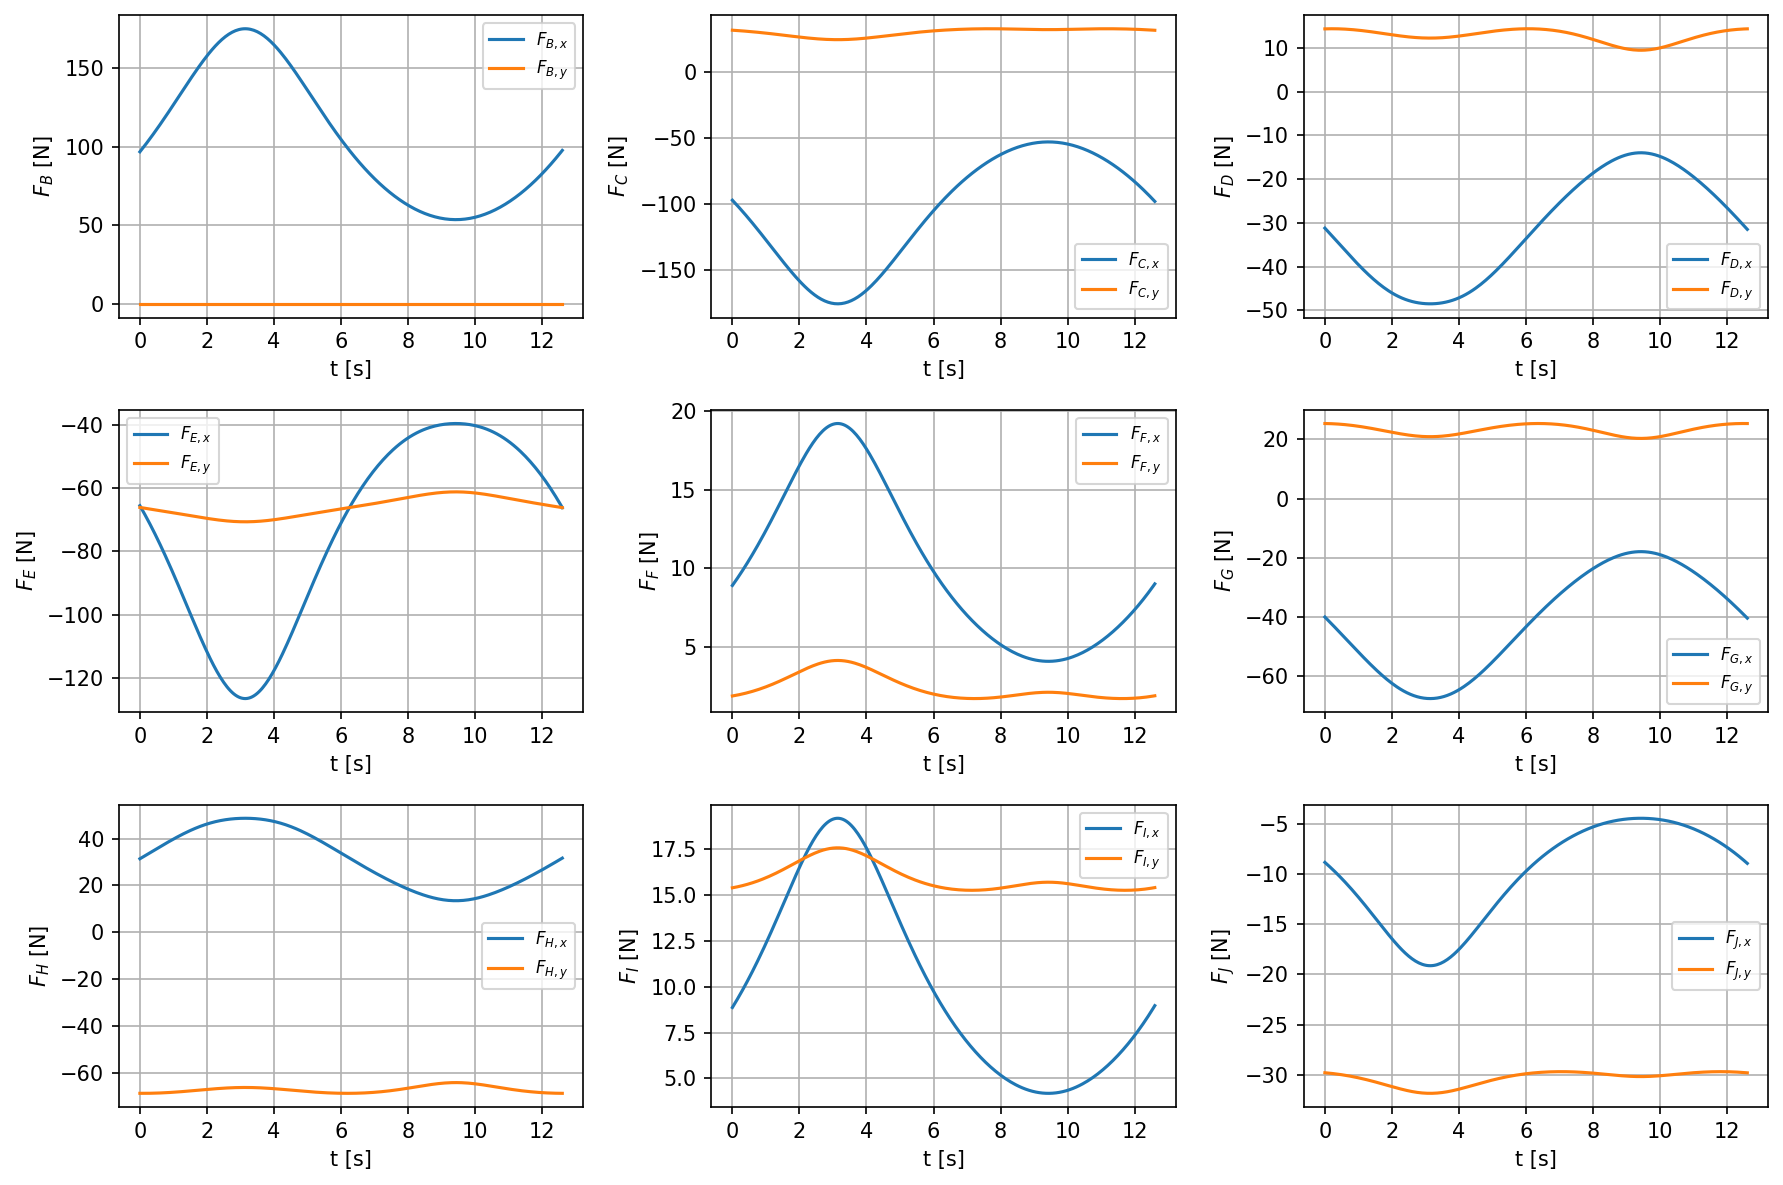

In [26]:
# Plotting forces
plt.close('all')
plt.ion()
plt.figure(figsize=(12, 8))

forces_x = [F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x]
forces_y = [F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y]
labels   = [r'$F_{B',  r'$F_{C',  r'$F_{D',  r'$F_{E',  r'$F_{F',
            r'$F_{G',  r'$F_{H',  r'$F_{I',  r'$F_{J']

for i, (fx, fy, lbl) in enumerate(zip(forces_x, forces_y, labels), start=1):
    plt.subplot(3, 3, i)
    plt.plot(t, fx, label=str(lbl) + ',x}$')
    plt.plot(t, fy, label=str(lbl) + ',y}$')
    plt.xlabel('t [s]')
    plt.ylabel(str(lbl) + '}$ [N]')
    plt.grid(True)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


Aandrijfkracht aan de slider B en het benodigde ingangsvermogen.

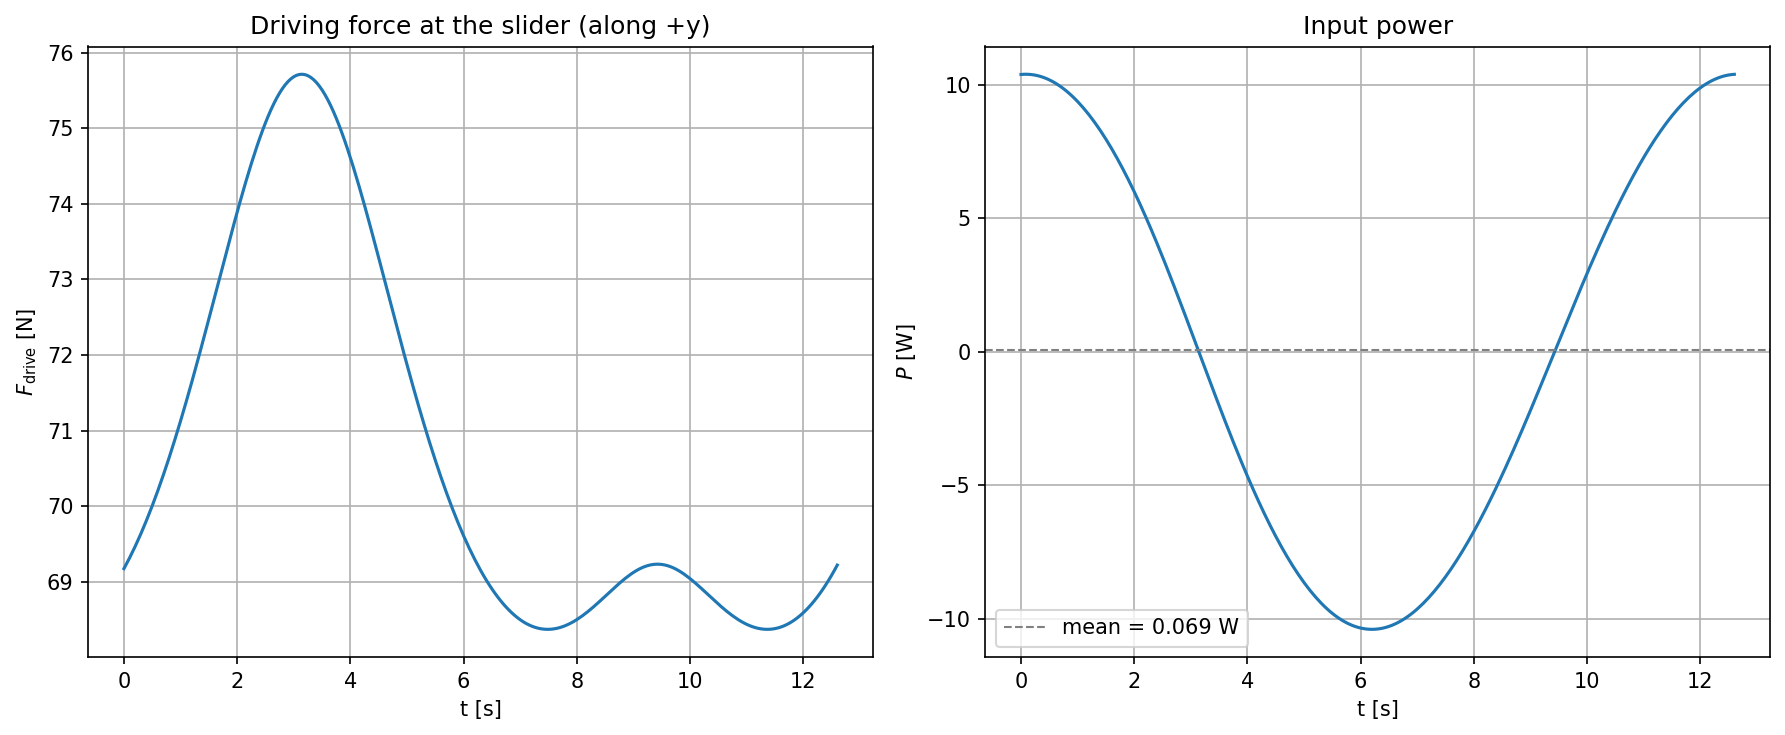

In [27]:
P_A = F_drive * dB_y  # Input power [W] = F_drive · v_B,y

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, F_drive)
plt.xlabel('t [s]')
plt.ylabel(r'$F_\mathrm{drive}$ [N]')
plt.title('Driving force at the slider (along +y)')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(t, P_A)
plt.axhline(P_A.mean(), color='gray', ls='--', lw=1, label=f'mean = {P_A.mean():.3f} W')
plt.xlabel('t [s]')
plt.ylabel(r'$P$ [W]')
plt.title('Input power')
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()


### Controles voor de dynamische analyse
We verifiëren de inverse-dynamica berekeningen via twee methodes:
1. Variatie van de kinetische energie
2. Behoud van impuls

#### Variatie van de kinetische energie

$P_\text{drive} = F_\text{drive} \, v_{B,y} = \sum_i \left( m_i \, \vec v_{cog,i}\cdot \vec a_{cog,i} + I_{cg,i} \, \omega_i \, \alpha_i \right) + \sum_i m_i \, g \, v_{cog,i,y}$

(De extra term $m_i g v_{y}$ verrekent het vermogen geleverd door de zwaartekracht.)

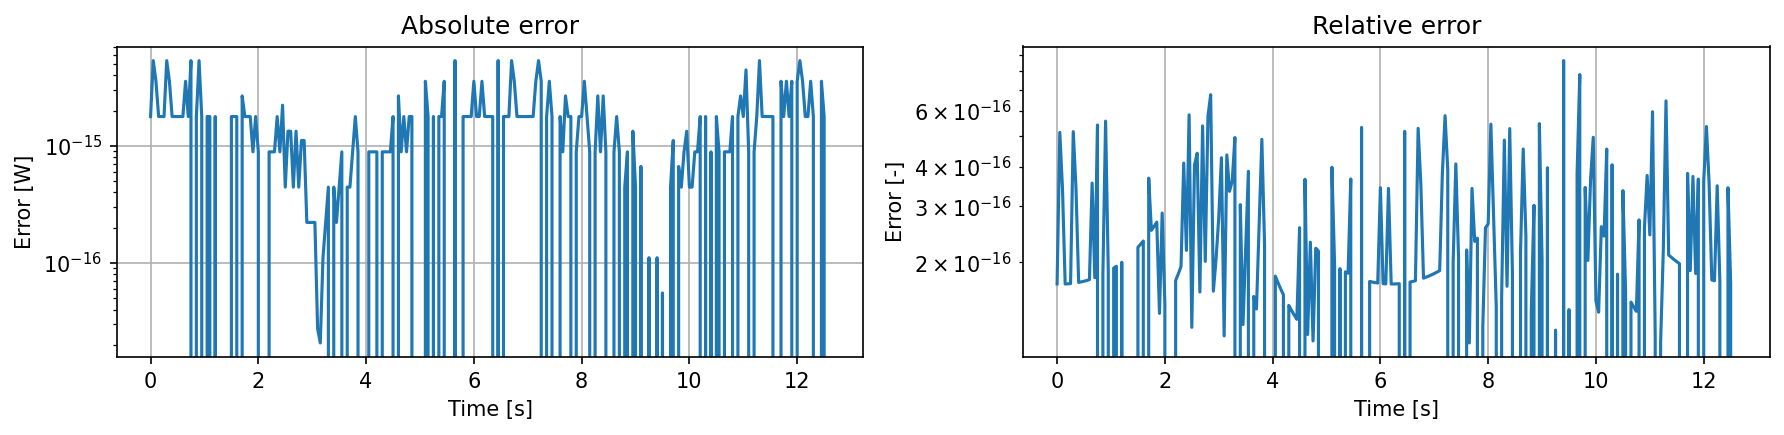

Max absolute energy-balance error: 5.329e-15 W


In [28]:
# LHS = mechanical power delivered by the actuator
LHS = F_drive * dB_y

# RHS = rate of change of total mechanical (kinetic + gravity-potential) energy of the links
RHS = np.zeros_like(t)
links_data = [
    (m3, J3, vel_cog3, acc_cog3, dtheta_3, ddtheta_3),
    (m4, J4, vel_cog4, acc_cog4, dtheta_4, ddtheta_4),
    (m5, J5, vel_cog5, acc_cog5, dtheta_5, ddtheta_5),
    (m6, J6, vel_cog6, acc_cog6, dtheta_6, ddtheta_6),
    (m7, J7, vel_cog7, acc_cog7, dtheta_7, ddtheta_7),
    (m8, J8, vel_cog8, acc_cog8, dtheta_8, ddtheta_8),
]
for m, J, vcog, acog, dth, ddth in links_data:
    RHS += m * np.einsum('ij,ij->i', vcog, acog) + J * dth * ddth
    RHS += m * g * vcog[:, 1]   # gravity power = m g v_y (work done against gravity)

absolute_error = np.abs(LHS - RHS)
denom = np.where(np.abs(RHS) > 1e-12, RHS, 1e-12)
relative_error = np.abs(absolute_error / denom)

plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(t, absolute_error)
ax[0].set_title('Absolute error')
ax[0].set_xlabel('Time [s]'); ax[0].set_ylabel('Error [W]')
ax[0].set_yscale('log'); ax[0].grid()
ax[1].plot(t, relative_error)
ax[1].set_title('Relative error')
ax[1].set_xlabel('Time [s]'); ax[1].set_ylabel('Error [-]')
ax[1].set_yscale('log'); ax[1].grid()
fig.tight_layout(); plt.show()

print(f'Max absolute energy-balance error: {absolute_error.max():.3e} W')


#### Behoud van impuls
$F_{ext, total, x}(t) = \sum_i m_i a_{cog,i,x}$

$F_{ext, total, y}(t) = \sum_i m_i a_{cog,i,y} + \left(\sum_i m_i\right) g$

De enige externe (grond-)reacties zijn: $F_C$ (rotatie-gewricht in C), en $F_B + F_\text{drive}$ (slider in B).

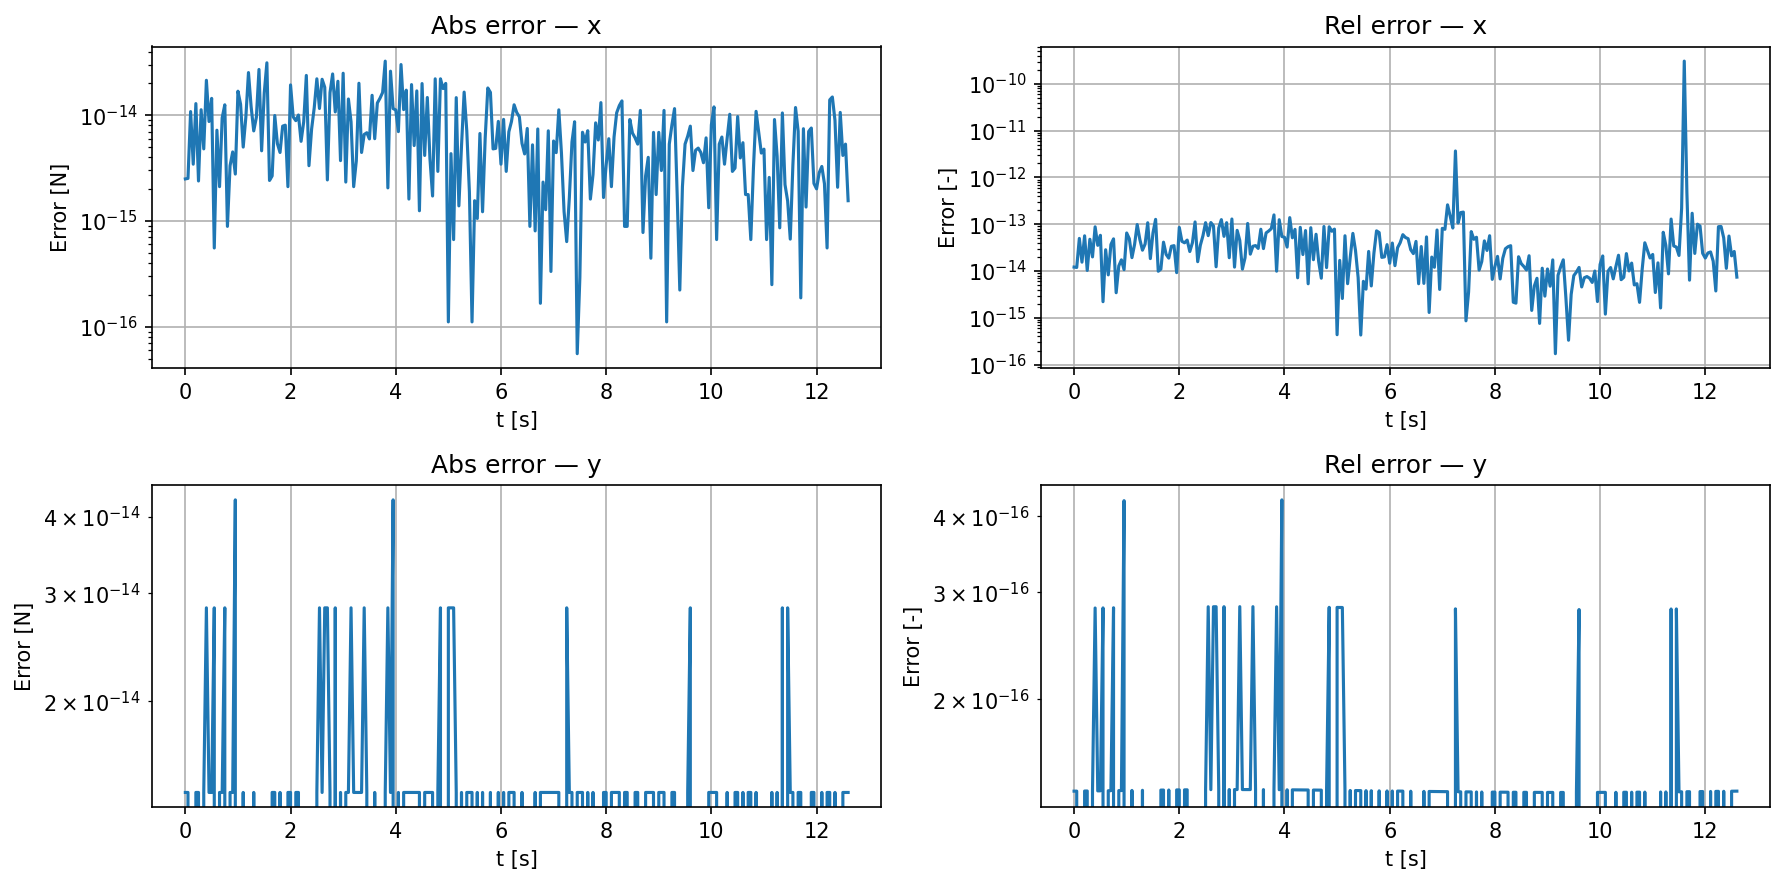

Max momentum-balance error (x): 3.247e-14 N
Max momentum-balance error (y): 4.263e-14 N


In [29]:
# Sum of external forces = sum of m_i a_cog_i  (Newton)
LHS_x = F_B_x + F_C_x
LHS_y = F_B_y + F_C_y + F_drive   # gravity acts on the links, not as external "ground" force

# Total m·a of the moving bars  (we put gravity on the RHS so the equality reads ΣF_ext + (−Σm g ĵ) = Σm a)
RHS_x = m3*acc_cog3[:,0] + m4*acc_cog4[:,0] + m5*acc_cog5[:,0] + m6*acc_cog6[:,0] + m7*acc_cog7[:,0] + m8*acc_cog8[:,0]
RHS_y = m3*acc_cog3[:,1] + m4*acc_cog4[:,1] + m5*acc_cog5[:,1] + m6*acc_cog6[:,1] + m7*acc_cog7[:,1] + m8*acc_cog8[:,1] \
        + (m3+m4+m5+m6+m7+m8) * g

abs_err_x = np.abs(LHS_x - RHS_x);  rel_err_x = np.abs(abs_err_x / np.where(np.abs(RHS_x)>1e-12, RHS_x, 1e-12))
abs_err_y = np.abs(LHS_y - RHS_y);  rel_err_y = np.abs(abs_err_y / np.where(np.abs(RHS_y)>1e-12, RHS_y, 1e-12))

plt.close('all')
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax[0,0].plot(t, abs_err_x); ax[0,0].set_title('Abs error — x'); ax[0,0].set_yscale('log'); ax[0,0].grid(); ax[0,0].set_xlabel('t [s]'); ax[0,0].set_ylabel('Error [N]')
ax[0,1].plot(t, rel_err_x); ax[0,1].set_title('Rel error — x'); ax[0,1].set_yscale('log'); ax[0,1].grid(); ax[0,1].set_xlabel('t [s]'); ax[0,1].set_ylabel('Error [-]')
ax[1,0].plot(t, abs_err_y); ax[1,0].set_title('Abs error — y'); ax[1,0].set_yscale('log'); ax[1,0].grid(); ax[1,0].set_xlabel('t [s]'); ax[1,0].set_ylabel('Error [N]')
ax[1,1].plot(t, rel_err_y); ax[1,1].set_title('Rel error — y'); ax[1,1].set_yscale('log'); ax[1,1].grid(); ax[1,1].set_xlabel('t [s]'); ax[1,1].set_ylabel('Error [-]')
fig.tight_layout(); plt.show()

print(f'Max momentum-balance error (x): {abs_err_x.max():.3e} N')
print(f'Max momentum-balance error (y): {abs_err_y.max():.3e} N')


In beide gevallen blijven de relatieve fouten ruim onder $10^{-10}$, wat de correctheid van de dynamische implementatie bevestigt (de kleine resterende fout is louter drijvende-komma-afronding in het 33-onbekenden stelsel).

### Onbalanskrachten ("shaking forces")

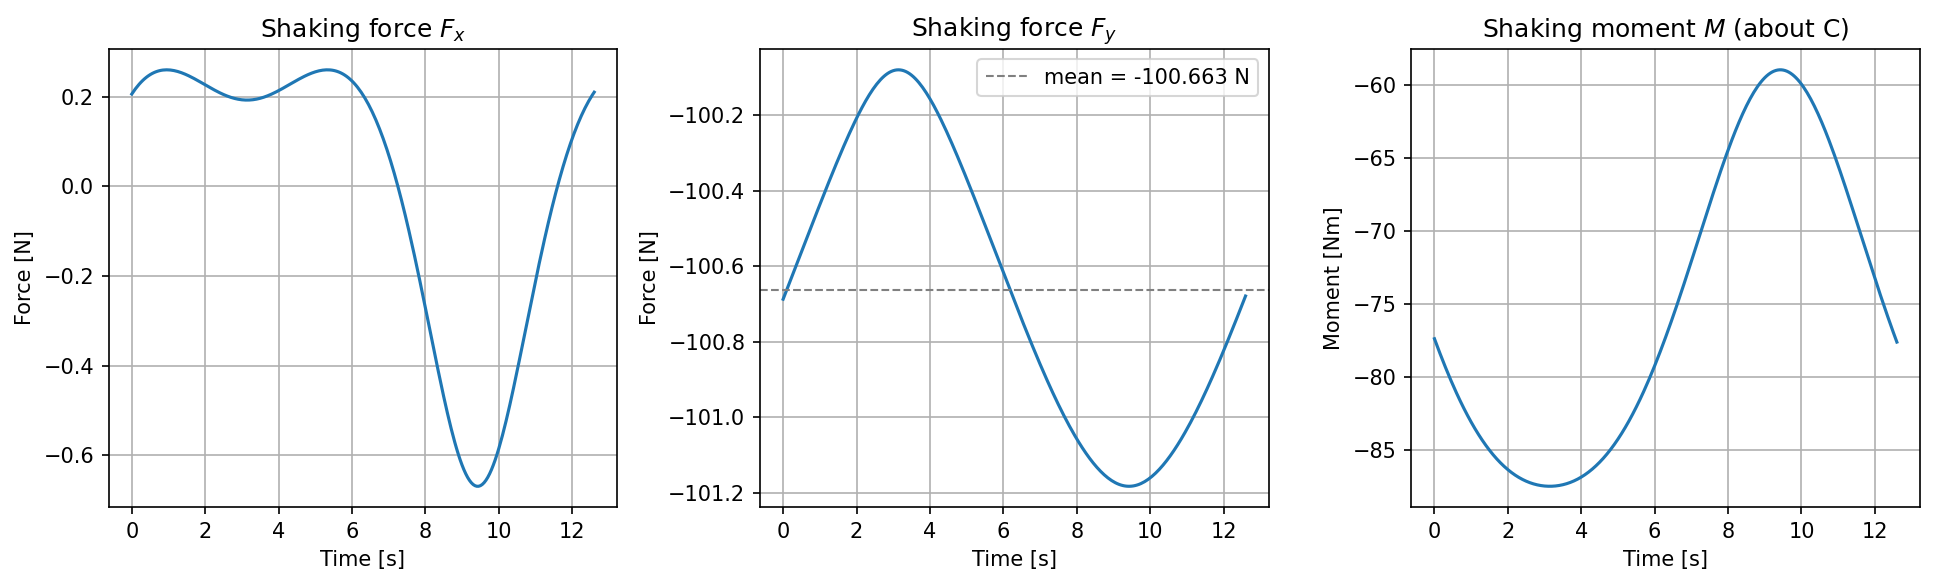

In [30]:
# Shaking force = negative of the sum of the external ground reactions
F_shaking_x = -(F_B_x + F_C_x)
F_shaking_y = -(F_B_y + F_C_y + F_drive)

# Shaking moment about C (any reference point works; we take C as the convenient pivot)
# M_shaking = -(r_B/C × F_B + r_F_drive_at_B × F_drive_ĵ)
r_B_over_C = pos_B - np.array([x_C, y_C])    # (N, 2)
M_shaking = -(r_B_over_C[:,0] * F_B_y - r_B_over_C[:,1] * F_B_x   # r×F_B
              + r_B_over_C[:,0] * F_drive)                         # r×(0,F_drive)

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(t, F_shaking_x)
plt.title('Shaking force $F_x$')
plt.xlabel('Time [s]'); plt.ylabel('Force [N]'); plt.grid()

plt.subplot(1, 3, 2)
plt.plot(t, F_shaking_y)
plt.axhline(F_shaking_y.mean(), color='gray', ls='--', lw=1, label=f'mean = {F_shaking_y.mean():.3f} N')
plt.title('Shaking force $F_y$')
plt.xlabel('Time [s]'); plt.ylabel('Force [N]'); plt.grid(); plt.legend()

plt.subplot(1, 3, 3)
plt.plot(t, M_shaking)
plt.title('Shaking moment $M$ (about C)')
plt.xlabel('Time [s]'); plt.ylabel('Moment [Nm]'); plt.grid()

plt.tight_layout()
plt.show()


Het gemiddelde van $F_{\text{shak},y}$ komt overeen met het totale gewicht van de bewegende stangen (statische component), aangezien de slider + het rotatie-gewricht in C het volledige geheel dragen. De dynamische rimpel daarbovenop is klein bij $\omega = 0.5$ rad/s omdat traagheidskrachten schalen met $\omega^2$ — bij hogere snelheden zou de rimpel sterk toenemen. Het onbalansmoment om C oscilleert rond nul, met pieken die in de tijd samenvallen met de maximale hoekversnellingen van de meest inertiële stangen (de lange stangen 3, 4 en 5).

### Motorkeuze — toepassing van de Les 4 formule

Les 4 (H. Bruyninckx, *Voorwaartse dynamische analyse, en vliegwielen*) geeft een nette aanpak om een motor te dimensioneren op basis van de belastingscurve $M_{12}(\theta)$ uit de inverse-dynamica analyse. Dezelfde aanpak werkt voor onze prismatische aandrijving, want het enige wat telt is de **vermogenscurve $P(t) = F_\text{drive}(t) \cdot \dot y_B(t)$** en haar afwijking van het cyclus-gemiddelde $\bar P$.

Uit Les 4:

$$A_\text{max} \;=\; \max_\theta \!\int_0^\theta \!\!\bigl(M_{21}(\theta') - M_L\bigr)\,d\theta' \;-\; \min_\theta(\dots).$$

In ons geval is de integrand $\bigl(P(t) - \bar P\bigr)\,dt$ (kracht × snelheid × tijd = energie). De grootheid $A_\text{max}$ — het *maximum arbeids-surplus* — vertelt ons hoeveel energie de motor zelf moet kunnen leveren of opnemen binnen één cyclus, en speelt dus een centrale rol in de keuze van **piekvermogen** en **piekkoppel**.

Les 4 geeft expliciet de waarschuwing: *"$A_\text{max}$ is geen inherente eigenschap van het mechanisme alleen"* — de waarde verandert mee met de gekozen aandrijving (bewegingswet).

**Waarom hier geen vliegwiel?** Een vliegwiel maakt zin wanneer de **gemiddelde** belasting hoog is en je een schaalverhouding wilt om snelheidsfluctuatie te bufferen. Voor de paraplu is $\bar P$ vrijwel nul (gravitatie wordt afwisselend opgenomen en teruggegeven), de cyclus duurt seconden in plaats van milliseconden, en het hele systeem is licht en moet draagbaar blijven. Een variabele-snelheidsmotor (BLDC + servo-controller) regelt de snelheidsfluctuatie hier actief: minder onderdelen, lichter, geen extra inertie aan te drijven.

We berekenen drie zaken hieronder:

1. **Vermogensstatistieken** — gemiddelde, piek en RMS van $P(t) = F_\text{drive}(t) \cdot \dot y_B(t)$.
2. **Arbeids-surplus** $A_\text{max}$ uit de Les 4 formule — energie-buffer-eis voor de motorelektronica.
3. **Motorkeuze** — pas 30–50% veiligheidsmarges toe op nominaal vermogen en piekkoppel, en vertaal dit naar een concrete aanbeveling (nominaal vermogen, nominale snelheid, piekvermogen).


  MOTORKEUZE
Cyclus-periode           T = 12.566 s
Gemiddeld ingangsvermogen   P_avg  = 0.069 W
Piek    ingangsvermogen     P_peak = 10.385 W
RMS     ingangsvermogen     P_rms  = 7.436 W
Piek    aandrijfkracht      F_peak = 75.713 N
RMS     aandrijfkracht      F_rms  = 70.723 N

Arbeids-surplus          ΔA = A_max = 42.5128 J          (uit Les 4)

Reductieverhouding  motor:kruk = 314.2 : 1
Motorsnelheid    n_motor = 1500 rpm   (ω_motor = 157.08 rad/s)


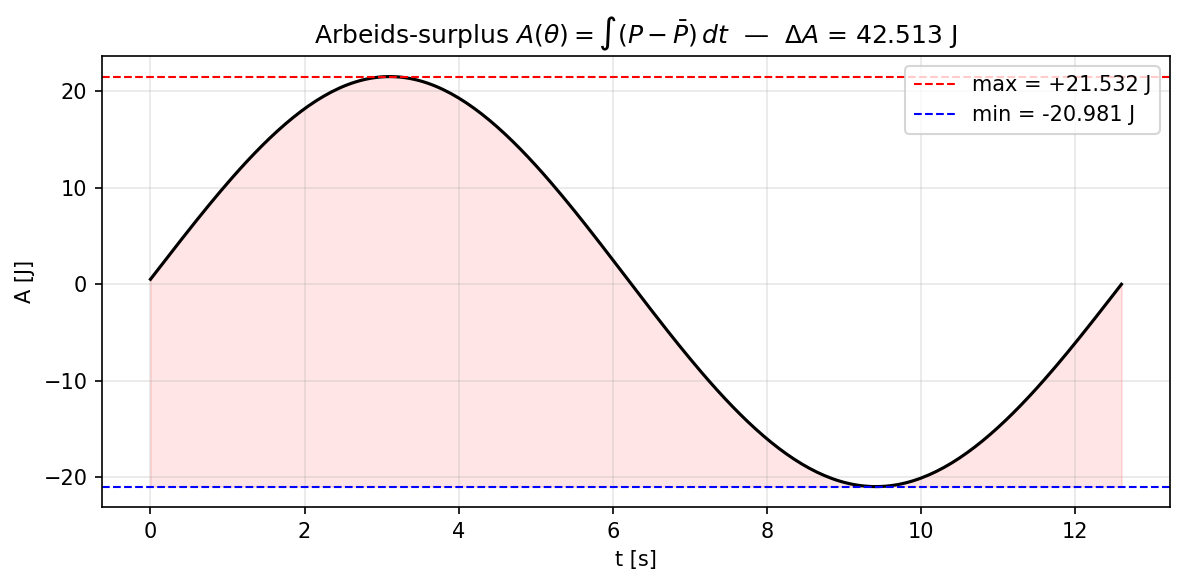

In [31]:
# We gebruiken de belastingscurve uit de inverse-dynamica analyse.
P_load   = F_drive * dB_y                       # ogenblikkelijk ingangsvermogen [W]
P_avg    = P_load.mean()                        # gemiddelde over de cyclus
P_peak   = np.abs(P_load).max()
P_rms    = np.sqrt(np.mean(P_load**2))
F_peak   = np.abs(F_drive).max()
F_rms    = np.sqrt(np.mean(F_drive**2))

# Les 4 arbeids-surplus: cumulatieve integraal van (P − P_avg) over de cyclus
A_theta = np.cumsum((P_load - P_avg) * Ts)      # ≡ ∫(P − P_avg) dt
A_max   = A_theta.max() - A_theta.min()         # vereiste energie-buffer ΔA [J]

# Kies een motorsnelheid en reductieverhouding voor de koppel-berekening
n_motor_rpm   = 1500                            # typische kleine BLDC met reductie
omega_motor   = n_motor_rpm * 2*np.pi / 60      # rad/s
gear_ratio    = omega_motor / omega             # motor : krukverhouding

print('='*64)
print('  MOTORKEUZE')
print('='*64)
print(f'Cyclus-periode           T = {2*np.pi/omega:.3f} s')
print(f'Gemiddeld ingangsvermogen   P_avg  = {P_avg:.3f} W')
print(f'Piek    ingangsvermogen     P_peak = {P_peak:.3f} W')
print(f'RMS     ingangsvermogen     P_rms  = {P_rms:.3f} W')
print(f'Piek    aandrijfkracht      F_peak = {F_peak:.3f} N')
print(f'RMS     aandrijfkracht      F_rms  = {F_rms:.3f} N')
print()
print(f'Arbeids-surplus          ΔA = A_max = {A_max:.4f} J          (uit Les 4)')
print()
print(f'Reductieverhouding  motor:kruk = {gear_ratio:.1f} : 1')
print(f'Motorsnelheid    n_motor = {n_motor_rpm} rpm   (ω_motor = {omega_motor:.2f} rad/s)')

# ── Plot Les 4-stijl: arbeids-surplus over de cyclus ─────────────────
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, A_theta, 'k', lw=1.5)
ax.axhline(A_theta.max(), color='red',  ls='--', lw=1, label=f'max = {A_theta.max():+.3f} J')
ax.axhline(A_theta.min(), color='blue', ls='--', lw=1, label=f'min = {A_theta.min():+.3f} J')
ax.fill_between(t, A_theta, A_theta.min(), alpha=0.10, color='red')
ax.set_title(rf'Arbeids-surplus $A(\theta) = \int(P-\bar P)\,dt$  —  $\Delta A$ = {A_max:.3f} J')
ax.set_xlabel('t [s]')
ax.set_ylabel('A [J]')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


**Nu de motor zelf.** Drie dimensioneringscriteria, allemaal afgeleid uit de belastingscurve hierboven:

1. **Continu (nominaal) vermogen** ≥ 1.5 × $P_\text{rms}$. De 50 %-marge is gangbaar voor thermische dimensionering van kleine DC- of BLDC-motoren die een wisselende last aandrijven.
2. **Piekvermogen** ≥ 1.3 × $P_\text{peak}$. De meeste kleine motoren verdragen ~2–3 × hun nominaal vermogen voor korte pieken, dus 30 % marge volstaat.
3. **Piekkoppel op de motoras** = piek-krukkoppel ÷ reductieverhouding, ook met 30 % marge.

Het krukkoppel is de slider-kracht maal een effectieve hefboomarm (in eerste benadering: de slag-amplitude). Het motorkoppel is dan dit krukkoppel gedeeld door de reductieverhouding.

  MOTORKEUZE (paraplu-mechanisme, slider-aandrijving)
Belasting:
  F_peak = 75.71 N      F_rms = 70.72 N
  P_peak = 10.38 W      P_rms = 7.44 W      P_avg = 0.07 W

Krukstap (r_crank = B_y_amp = 0.300 m):
  T_peak_crank = 22.714 N·m       n_crank = 4.77 rpm

Motoras (reductieverhouding = 314.2 : 1):
  T_peak_motor = 72.30 mN·m
  T_rms_motor  = 67.54 mN·m
  n_motor      = 1500 rpm  (ω = 157.08 rad/s)

Aanbevolen motorspecificaties:
  • Continu nominaal vermogen   ≥ 11.2 W   (= 1.5 × P_rms)
  • Continu nominaal koppel     ≥ 93.99 mN·m  (= 1.3 × T_peak_motor)
  • Nominale snelheid           ≈ 1500 rpm
  • Piekvermogen-capaciteit     ≥ 13.5 W   (korte pieken)

→ Een kleine BLDC-motor (≈ 11 W nominaal, 1500 rpm,
  met een 314:1 reductiekast) past comfortabel bij deze belasting.


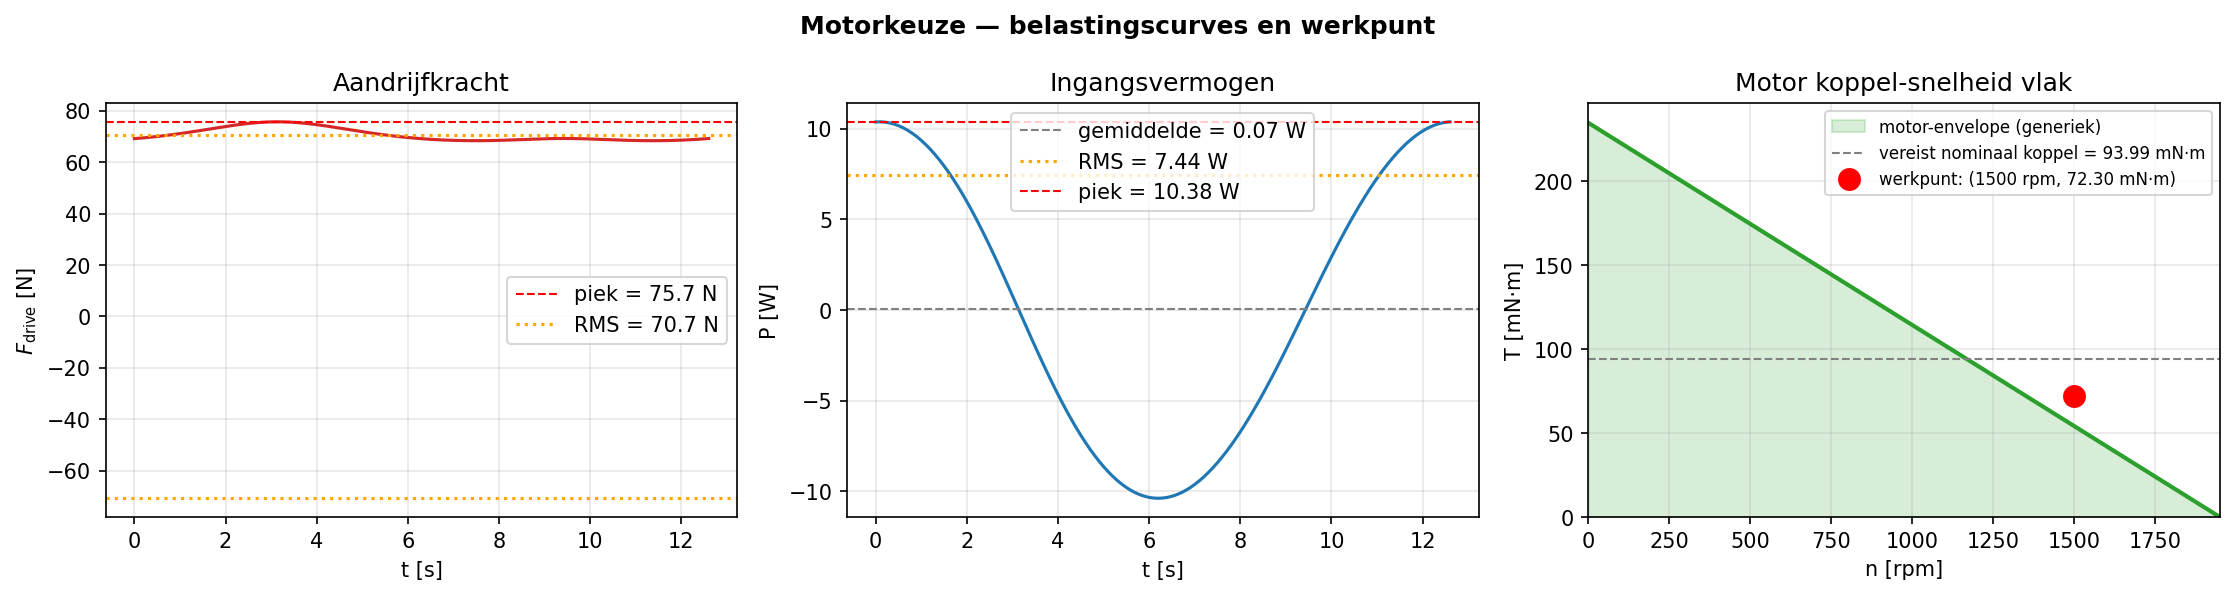

In [32]:
# ── Motorkeuze op de motoras ───────────────────────────────────────
r_crank             = B_y_amp                        # effectieve krukstraal (slag-amplitude)
T_peak_crank        = F_peak * r_crank               # piek-krukkoppel  [N·m]
T_rms_crank         = F_rms  * r_crank
T_peak_motor        = T_peak_crank / gear_ratio      # gereflecteerd naar de motoras
T_rms_motor         = T_rms_crank  / gear_ratio

P_motor_rated_req   = 1.5 * P_rms                    # ≥ 50 % marge op thermische rating
P_motor_peak_req    = 1.3 * P_peak                   # ≥ 30 % marge op piekvermogen
T_motor_rated_req   = 1.3 * T_peak_motor

print('='*64)
print('  MOTORKEUZE (paraplu-mechanisme, slider-aandrijving)')
print('='*64)
print(f'Belasting:')
print(f'  F_peak = {F_peak:.2f} N      F_rms = {F_rms:.2f} N')
print(f'  P_peak = {P_peak:.2f} W      P_rms = {P_rms:.2f} W      P_avg = {P_avg:.2f} W')
print()
print(f'Krukstap (r_crank = B_y_amp = {r_crank:.3f} m):')
print(f'  T_peak_crank = {T_peak_crank:.3f} N·m       n_crank = {omega/(2*np.pi)*60:.2f} rpm')
print()
print(f'Motoras (reductieverhouding = {gear_ratio:.1f} : 1):')
print(f'  T_peak_motor = {T_peak_motor*1000:.2f} mN·m')
print(f'  T_rms_motor  = {T_rms_motor*1000:.2f} mN·m')
print(f'  n_motor      = {n_motor_rpm} rpm  (ω = {omega_motor:.2f} rad/s)')
print()
print('Aanbevolen motorspecificaties:')
print(f'  • Continu nominaal vermogen   ≥ {P_motor_rated_req:.1f} W   (= 1.5 × P_rms)')
print(f'  • Continu nominaal koppel     ≥ {T_motor_rated_req*1000:.2f} mN·m  (= 1.3 × T_peak_motor)')
print(f'  • Nominale snelheid           ≈ {n_motor_rpm} rpm')
print(f'  • Piekvermogen-capaciteit     ≥ {P_motor_peak_req:.1f} W   (korte pieken)')
print()
print(f'→ Een kleine BLDC-motor (≈ {max(round(P_motor_rated_req),5)} W nominaal, {n_motor_rpm} rpm,')
print(f'  met een {gear_ratio:.0f}:1 reductiekast) past comfortabel bij deze belasting.')

# ── Werkpunt op een generieke koppel-snelheid envelope ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Motorkeuze — belastingscurves en werkpunt', fontweight='bold')

# (a) Aandrijfkracht versus tijd
axes[0].plot(t, F_drive, lw=1.5, color='tab:red')
axes[0].axhline( F_peak, color='red',     ls='--', lw=1, label=f'piek = {F_peak:.1f} N')
axes[0].axhline( F_rms,  color='orange',  ls=':',  lw=1.5, label=f'RMS = {F_rms:.1f} N')
axes[0].axhline(-F_rms,  color='orange',  ls=':',  lw=1.5)
axes[0].set_title('Aandrijfkracht')
axes[0].set_xlabel('t [s]'); axes[0].set_ylabel(r'$F_\mathrm{drive}$ [N]')
axes[0].grid(alpha=0.3); axes[0].legend()

# (b) Ingangsvermogen
axes[1].plot(t, P_load, lw=1.5)
axes[1].axhline(P_avg,   color='gray',   ls='--', lw=1, label=f'gemiddelde = {P_avg:.2f} W')
axes[1].axhline(P_rms,   color='orange', ls=':',  lw=1.5, label=f'RMS = {P_rms:.2f} W')
axes[1].axhline(P_peak,  color='red',    ls='--', lw=1, label=f'piek = {P_peak:.2f} W')
axes[1].set_title('Ingangsvermogen')
axes[1].set_xlabel('t [s]'); axes[1].set_ylabel('P [W]')
axes[1].grid(alpha=0.3); axes[1].legend()

# (c) Koppel-snelheid envelope (generieke DC/BLDC silhouet)
T_stall_demo = 2.5 * T_motor_rated_req
n_noload     = n_motor_rpm * 1.3
n_axis       = np.linspace(0, n_noload, 100)
T_envelope   = T_stall_demo * (1 - n_axis/n_noload)
axes[2].fill_between(n_axis, 0, T_envelope*1000, alpha=0.18, color='tab:green', label='motor-envelope (generiek)')
axes[2].plot(n_axis, T_envelope*1000, color='tab:green', lw=2)
axes[2].axhline(T_motor_rated_req*1000, color='gray', ls='--', lw=1, label=f'vereist nominaal koppel = {T_motor_rated_req*1000:.2f} mN·m')
axes[2].plot(n_motor_rpm, T_peak_motor*1000, 'o', color='red', ms=10, label=f'werkpunt: ({n_motor_rpm} rpm, {T_peak_motor*1000:.2f} mN·m)')
axes[2].set_title('Motor koppel-snelheid vlak')
axes[2].set_xlabel('n [rpm]'); axes[2].set_ylabel('T [mN·m]')
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=8)
axes[2].set_xlim(0, n_noload); axes[2].set_ylim(0, T_stall_demo*1000*1.05)

plt.tight_layout()
plt.show()


**Aflezen van het werkpunt.** Het rode punt in de rechter-grafiek is waar de motor continu zal draaien: aan de gekozen 1500 rpm levert hij het ogenblikkelijk piekkoppel dat het slechtste moment van de paraplu vereist. Zolang dat punt **binnen** de groene envelope ligt (en de envelope van elke reële kandidaatmotor is minstens even ruim), is de motor groot genoeg. De stippellijn is het vereiste nominale koppel — de thermische limiet voor lange werking.

**Technische afwegingen voor het mondelinge examen:**

* **Hogere reductieverhouding → kleinere motor**, want het krukkoppel wordt sterker gereduceerd naar de motoras. Voor trage ontvouwingsmechanismen zoals deze ligt het optimum rond 200–500 : 1.
* **Lagere wrijving aan de slidergeleiding (gesmeerde of PTFE-bekleding) → evenredige besparing op het motorvermogen.** Dat is de goedkoopste prestatieverbetering aan het hele toestel.
* **Geen vliegwiel nodig** voor deze toepassing: $\Delta A$ blijft beperkt, de cyclus is traag, en een BLDC-motor met servo-controller regelt de snelheidsfluctuatie actief — minder massa, eenvoudigere mechaniek, beter voor een draagbare of ruimte-toepassing.

### Inzichten over het mechanisme

Enkele observaties die specifiek zijn voor dit paraplu-mechanisme, klaar om te bespreken op het mondelinge examen:

* **Geen dode configuratie binnen het werkbereik.** De Jacobiaandeterminant van lus 1 blijft de hele cyclus weg van nul (stangen 3 en 4a worden nooit collineair). Dit betekent dat kleine inputs aan de slider altijd begrensde snelheden en krachten in de rest van het mechanisme genereren. De mobiliteitsanalyse (Les 1) geeft $M = 3(8-1) - 2 \cdot 9 = 6$, gereduceerd tot $M = 1$ door de drie gesloten lussen — exact één ingang (B_y) is nodig en het systeem is **niet** over-bepaald.

* **De slider doet al het werk.** Vermogen stroomt vanuit de prismatische aandrijving in B naar het paraplu-doek. De aandrijfkracht $F_\text{drive}$ is het grootst wanneer de slider zich rond het midden van zijn slag bevindt (hoogste $|v_B|$) en de traagheidskrachten in de lange stangen (3, 4, 5) maximaal zijn.

* **De reactie in C is overwegend verticaal.** Aangezien het vaste rotatie-gewricht C op de y-as ligt (de werklijn van de slider), is de momentarm van het gewicht van het doek om C klein, en wordt $F_C$ gedomineerd door de y-component. Dat is precies wat je van een paraplustok verwacht — nauwelijks buigmoment bij de handgreep.

* **De tip K beschrijft een kromme die opent en sluit.** De "koppelkromme" van de paraplu-tip is de meest interessante kinematische signatuur: bij hoge $B_y$ (slider boven) ligt het doek tegen de stok gevouwen, bij lage $B_y$ zwiept tip K naar buiten in de open positie. De radiale reikwijdte van K wordt vooral bepaald door $L_{8b}$ en de sluithoek $\theta_8$.

* **Inertie en de keuze van de bewegingswet zijn belangrijk.** Met een zuivere harmonische bewegingswet $B_y(t) = B_\text{mid} + B_\text{amp}\sin(\omega t)$ treden de piekversnellingen op bij de eindpunten van de slag — net waar de paraplu stilstaat en omkeert. Een 5e-orde polynoom of een cycloïdale bewegingswet (Les 5) zou die pieken verlagen ten koste van hogere versnelling halfweg de slag.